In [1]:
# PubChem에서 벌크 파일 다운로드 받아서 진행하기 (로컬(Terpenoid.ipynb)보다 안정적일듯)

!wget https://ftp.ncbi.nlm.nih.gov/pubchem/Compound/Extras/CID-InChI-Key.gz

--2026-06-03 14:45:58--  https://ftp.ncbi.nlm.nih.gov/pubchem/Compound/Extras/CID-InChI-Key.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.13, 130.14.250.12, 2607:f220:41e:250::11, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7313351290 (6.8G) [application/x-gzip]
Saving to: ‘CID-InChI-Key.gz’

 1% [                                       ] 80,943,541  1.42MB/s   in 5m 6s  

2026-06-03 14:51:06 (258 KB/s) - Connection closed at byte 80943541. Retrying.

--2026-06-03 14:51:07--  (try: 2)  https://ftp.ncbi.nlm.nih.gov/pubchem/Compound/Extras/CID-InChI-Key.gz
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.13|:443... connected.
HTTP request sent, awaiting response... 206 Partial Content
Length: 7313351290 (6.8G), 7232407749 (6.7G) remaining [application/x-gzip]
Saving to: ‘CID-InChI-Key.gz’

100%[====================================>] 7,313,3

In [2]:
!ls -lh CID-InChI-Key.gz

-rw-rw-r-- 1 sjkim sjkim 6.9G Jun  1 18:17 CID-InChI-Key.gz


In [3]:
import pandas as pd

df = pd.read_csv("/work/home/sjkim/DNA_to_Protein/Spring/COCONUT/coconut_csv-04-2026.csv")
print(df.shape)
print(df.columns.tolist())

/work/home/sjkim/anaconda3/envs/py38/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3508: DtypeWarning: Columns (38) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


(738827, 44)
['identifier', 'canonical_smiles', 'standard_inchi', 'standard_inchi_key', 'name', 'iupac_name', 'annotation_level', 'total_atom_count', 'heavy_atom_count', 'molecular_weight', 'exact_molecular_weight', 'molecular_formula', 'alogp', 'topological_polar_surface_area', 'rotatable_bond_count', 'hydrogen_bond_acceptors', 'hydrogen_bond_donors', 'hydrogen_bond_acceptors_lipinski', 'hydrogen_bond_donors_lipinski', 'lipinski_rule_of_five_violations', 'aromatic_rings_count', 'qed_drug_likeliness', 'formal_charge', 'fractioncsp3', 'number_of_minimal_rings', 'van_der_walls_volume', 'contains_sugar', 'contains_ring_sugars', 'contains_linear_sugars', 'murcko_framework', 'np_likeness', 'chemical_class', 'chemical_sub_class', 'chemical_super_class', 'direct_parent_classification', 'np_classifier_pathway', 'np_classifier_superclass', 'np_classifier_class', 'np_classifier_is_glycoside', 'organisms', 'collections', 'dois', 'synonyms', 'cas']


In [20]:
import pandas as pd

pubchem_reader = pd.read_csv(
    "CID-InChI-Key.gz",
    sep="\t",
    compression="gzip",
    header=None,
    names=["pubchem_compound_id", "standard_inchi", "standard_inchi_key"],
    chunksize=1_000_000
)

first_chunk = next(pubchem_reader)

first_chunk.head()

,pubchem_compound_id,standard_inchi,standard_inchi_key
0,1,InChI=1S/C9H17NO4/c1-7(11)14-8(5-9(12)13)6-10(...,RDHQFKQIGNGIED-UHFFFAOYSA-N
1,2,InChI=1S/C9H17NO4/c1-7(11)14-8(5-9(12)13)6-10(...,RDHQFKQIGNGIED-UHFFFAOYSA-O
2,3,InChI=1S/C7H8O4/c8-5-3-1-2-4(6(5)9)7(10)11/h1-...,INCSWYKICIYAHB-UHFFFAOYSA-N
3,4,"InChI=1S/C3H9NO/c1-3(5)2-4/h3,5H,2,4H2,1H3",HXKKHQJGJAFBHI-UHFFFAOYSA-N
4,5,"InChI=1S/C3H8NO5P/c4-1-3(5)2-9-10(6,7)8/h1-2,4...",HIQNVODXENYOFK-UHFFFAOYSA-N


In [23]:
terp = df[df["np_classifier_pathway"] == "Terpenoids"].copy()

print("Terpenoids:", len(terp))
terp.head()

Terpenoids: 209865


,identifier,canonical_smiles,standard_inchi,standard_inchi_key,name,iupac_name,annotation_level,total_atom_count,heavy_atom_count,molecular_weight,...,direct_parent_classification,np_classifier_pathway,np_classifier_superclass,np_classifier_class,np_classifier_is_glycoside,organisms,collections,dois,synonyms,cas
1,CNP0114775.1,C=C1[C@@H]2C[C@H](OC(C)=O)[C@@H]3[C@@](CC(=O)[...,InChI=1S/C28H38O9/c1-13-18-9-20(34-14(2)29)24-...,HJVZODUKGZYRNN-ULMPZENDSA-N,NaN,"[(1~{S},4~{R},6~{S},8~{S},9~{S},10~{R},11~{S},...",1,75,37,518.60,...,Kaurane diterpenoids,Terpenoids,Diterpenoids,Kaurane and Phyllocladane diterpenoids,False,Isodon inflexus,Super Natural II|WikiData Natural Products,10.1016/0031-9422(89)80128-1,NaN,NaN
2,CNP0030601.2,CC(C)[C@H]1CC[C@H]([C@@]2(O)CC[C@H]3[C@@H]4CCC...,InChI=1S/C27H40O4/c1-16(2)23-8-7-22(24(29)31-2...,QWDVZDQDEVDTOE-DLDPTGDWSA-N,Anastomosacetal A,"(8R,9S,10R,13S,14S,17S)-17-hydroxy-17-[(2R,3R,...",0,71,31,428.61,...,NaN,Terpenoids,Steroids,Ergostane steroids,True,Euplexaura anastomosans,WikiData Natural Products,10.1021/NP960543F,"|(10R,13S,17S)-17-hydroxy-17-((2R,3R,6R)-2-hyd...",NaN
3,CNP0330217.1,CC(=O)O[C@H]1C[C@@]2(C)C(=O)CCC(C)=C2[C@H]2OC(...,InChI=1S/C17H22O5/c1-8-5-6-12(19)17(4)7-11(21-...,ATWFGCRPHGGEQP-BZDSGMRHSA-N,NaN,"[(3~{S},3~{a}~{R},4~{S},5~{a}~{R},9~{b}~{S})-3...",4,44,22,306.36,...,"Eudesmanolides, secoeudesmanolides, and deriva...",Terpenoids,Sesquiterpenoids,Eudesmane sesquiterpenoids,False,Artemisia herba-alba,ANPDB|NANPDB (Natural Products from Northern A...,10.1021/NP50109A010|10.1021/np50109a010,8alpha-acetoxytaurin,NaN
12,CNP0367135.9,C[C@]12CC[C@H]3[C@H](CCC4=CC(=O)CC[C@@]43C)[C@...,InChI=1S/C36H44O2/c1-33-20-18-28(37)24-27(33)1...,OHAANEIIOVTZON-BBJWTENBSA-N,NaN,"(8~{R},9~{S},10~{R},13~{S},14~{S},17~{S})-10,1...",1,82,38,508.75,...,"Gluco\/mineralocorticoids, progestogins and de...",Terpenoids,Steroids,Androstane steroids,False,NaN,Super Natural II,NaN,NaN,NaN
16,CNP0292655.1,C=C(C)[C@@H](C)CC[C@@H](C)[C@H]1CC[C@H]2[C@@H]...,InChI=1S/C28H46O/c1-18(2)19(3)7-8-20(4)24-11-1...,IBAFJAONJZIYIT-ZRUUVFCLSA-N,Codisterol,"(3~{S},8~{S},9~{S},10~{R},13~{R},14~{S},17~{R}...",3,75,29,398.68,...,Ergosterols and derivatives,Terpenoids,Steroids,Cholestane steroids,False,Ajuga reptans|Aplysina fistularis|Codium decor...,FooDB|Super Natural II|WikiData Natural Products,10.1007/BF02535649|10.1007/BF02536432|10.1007/...,52936-69-3|Codisterol|DTXSID501318542|Ergosta-...,52936-69-3


In [25]:
terp_map = terp[
    [
        "identifier",
        "name",
        "iupac_name",
        "canonical_smiles",
        "standard_inchi",
        "standard_inchi_key",
        "np_classifier_pathway",
        "np_classifier_superclass",
        "np_classifier_class"
    ]
].copy()

terp_map = terp_map.dropna(subset=["standard_inchi_key"])
terp_map = terp_map.drop_duplicates(subset=["standard_inchi_key"])

print(len(terp_map))

209675


In [27]:
target_keys = set(terp_map["standard_inchi_key"])

matches = []

pubchem_reader = pd.read_csv(
    "CID-InChI-Key.gz",
    sep="\t",
    compression="gzip",
    header=None,
    names=[
        "pubchem_compound_id",
        "standard_inchi",
        "standard_inchi_key"
    ],
    chunksize=1_000_000
)

for chunk in pubchem_reader:
    
    hit = chunk[
        chunk["standard_inchi_key"].isin(target_keys)
    ]

    if len(hit) > 0:
        matches.append(hit) 

In [28]:
pubchem_mapping = pd.concat(
    matches,
    ignore_index=True
)

print(pubchem_mapping.shape)

pubchem_mapping.head()

(183820, 3)


,pubchem_compound_id,standard_inchi,standard_inchi_key
0,325,InChI=1S/C10H14O/c1-8(2)10-5-3-9(7-11)4-6-10/h...,OIGWAXDAPKFNCQ-UHFFFAOYSA-N
1,326,InChI=1S/C10H12O/c1-8(2)10-5-3-9(7-11)4-6-10/h...,WTWBUQJHJGUZCY-UHFFFAOYSA-N
2,633,InChI=1S/C50H70O2/c1-38(2)19-12-20-39(3)21-13-...,GDUBPWSFXUAETN-UHFFFAOYSA-N
3,647,"InChI=1S/C5H12O7P2/c1-5(2)3-4-11-14(9,10)12-13...",CBIDRCWHNCKSTO-UHFFFAOYSA-N
4,1107,InChI=1S/C17H28O/c18-13-6-9-15-12(10-13)5-8-16...,FPXSXMFOYWRHDX-UHFFFAOYSA-N


In [29]:
# 여기까지가 COCONUT과 pubchem id (CID) mapping 과정
terp_pubchem = terp_map.merge(
    pubchem_mapping[
        [
            "standard_inchi_key",
            "pubchem_compound_id"
        ]
    ],
    on="standard_inchi_key",
    how="left"
)

print("전체:", len(terp_pubchem))

print(
    "CID 매핑 성공:",
    terp_pubchem["pubchem_compound_id"]
    .notna()
    .sum()
)

print(
    "매핑률:",
    terp_pubchem["pubchem_compound_id"]
    .notna()
    .mean()
)

전체: 209820
CID 매핑 성공: 183820
매핑률: 0.8760842627013631


In [30]:
# 최종 Terpenoid-CID.csv 저장

terp_pubchem_matched = terp_pubchem[
    terp_pubchem["pubchem_compound_id"].notna()
].copy()

terp_pubchem_matched.to_csv(
    "terpenoids_pubchem_mapped_full.csv",
    index=False
)

print(terp_pubchem_matched.shape)

(183820, 10)


In [31]:
#terpenoids_pubchem_mapped_full.csv에는 여러 컬럼이 존재하며, 이로부터 chemical과 CID만 남긴 csv 파일을 새로 저장

terpenoid_chemical_pubchem = terp_pubchem_matched.copy()

terpenoid_chemical_pubchem["chemical"] = terpenoid_chemical_pubchem["name"]
terpenoid_chemical_pubchem["chemical"] = terpenoid_chemical_pubchem["chemical"].fillna(
    terpenoid_chemical_pubchem["iupac_name"]
)
terpenoid_chemical_pubchem["chemical"] = terpenoid_chemical_pubchem["chemical"].fillna(
    terpenoid_chemical_pubchem["identifier"]
)

terpenoid_chemical_pubchem = terpenoid_chemical_pubchem[
    ["chemical", "pubchem_compound_id"]
].drop_duplicates()

terpenoid_chemical_pubchem.to_csv(
    "terpenoid_chemical_pubchem_compound_id.csv",
    index=False
)

terpenoid_chemical_pubchem.head()

,chemical,pubchem_compound_id
0,"[(1~{S},4~{R},6~{S},8~{S},9~{S},10~{R},11~{S},...",162852309.0
1,Anastomosacetal A,10646207.0
2,"[(3~{S},3~{a}~{R},4~{S},5~{a}~{R},9~{b}~{S})-3...",101248755.0
3,"(8~{R},9~{S},10~{R},13~{S},14~{S},17~{S})-10,1...",51444222.0
4,Codisterol,13833114.0


In [ ]:
# 이제 CTD에서 therapeutic assciations 정보가 있는지 확인해야함.

진행과정 (ctd_disease_chemical_phenolexplorer_therapeutic.csv,ctd_polyphenols_implicit_explicit.csv 파일을 terpenoids 관련 파일로 바꾸는 과정임.)
1. Terpenoid PubChem CID 매핑 (COCONUT - PubChem)
2. PubChem CID - CTD Chemical ID mapping
3. CTD chemical-disease associations
4. DirectEvidence == therapeutic 필터

In [40]:
# CTD 파일 다운로드

!wget http://ctdbase.org/reports/CTD_chemicals_diseases.csv.gz
!wget http://ctdbase.org/reports/CTD_chemicals.csv.gz

--2026-06-03 16:50:06--  http://ctdbase.org/reports/CTD_chemicals_diseases.csv.gz
Resolving ctdbase.org (ctdbase.org)... 152.7.178.53
Connecting to ctdbase.org (ctdbase.org)|152.7.178.53|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://ctdbase.org/reports/CTD_chemicals_diseases.csv.gz [following]
--2026-06-03 16:50:06--  https://ctdbase.org/reports/CTD_chemicals_diseases.csv.gz
Connecting to ctdbase.org (ctdbase.org)|152.7.178.53|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 161566408 (154M) [application/octet-stream]
Saving to: ‘CTD_chemicals_diseases.csv.gz’

100%[======================================>] 161,566,408 14.3MB/s   in 21s    

2026-06-03 16:50:28 (7.48 MB/s) - ‘CTD_chemicals_diseases.csv.gz’ saved [161566408/161566408]

--2026-06-03 16:50:29--  http://ctdbase.org/reports/CTD_chemicals.csv.gz
Resolving ctdbase.org (ctdbase.org)... 152.7.178.53
Connecting to ctdbase.org (ctdbase.org)|152.7.178.53|:

In [60]:
# CTD 파일 다운로드 받기

import os
os.chdir("/work/home/sjkim/DNA_to_Protein/Spring/CTD")

!wget https://ctdbase.org/reports/CTD_curated_chemicals_diseases.csv.gz

!wget https://ctdbase.org/reports/CTD_chemicals.csv.gz

--2026-06-03 17:12:13--  https://ctdbase.org/reports/CTD_curated_chemicals_diseases.csv.gz
Resolving ctdbase.org (ctdbase.org)... 152.7.178.53
Connecting to ctdbase.org (ctdbase.org)|152.7.178.53|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2190148 (2.1M) [application/octet-stream]
Saving to: ‘CTD_curated_chemicals_diseases.csv.gz’

100%[======================================>] 2,190,148   1.94MB/s   in 1.1s   

2026-06-03 17:12:15 (1.94 MB/s) - ‘CTD_curated_chemicals_diseases.csv.gz’ saved [2190148/2190148]

--2026-06-03 17:12:16--  https://ctdbase.org/reports/CTD_chemicals.csv.gz
Resolving ctdbase.org (ctdbase.org)... 152.7.178.53
Connecting to ctdbase.org (ctdbase.org)|152.7.178.53|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10719804 (10M) [application/octet-stream]
Saving to: ‘CTD_chemicals.csv.gz’

100%[======================================>] 10,719,804  5.66MB/s   in 1.8s   

2026-06-03 17:12:19 (5.66 MB/s) - ‘CTD_chemic

In [61]:
import gzip

with gzip.open(
    "CTD_curated_chemicals_diseases.csv.gz",
    "rt",
    encoding="utf-8",
    errors="ignore"
) as f:

    for _ in range(50):
        print(next(f).rstrip())

# The Comparative Toxicogenomics Database (CTD) - http://ctdbase.org/
#   Copyright 2002-2012 MDI Biological Laboratory. All rights reserved.
#   Copyright 2012-2026 NC State University. All rights reserved.
#
#
# Use is subject to the terms set forth at http://ctdbase.org/about/legal.jsp
# These terms include:
#
#   1. All forms of publication (e.g., web sites, research papers, databases,
#      software applications, etc.) that use or rely on CTD data must cite CTD.
#      Citation guidelines: http://ctdbase.org/about/publications/#citing
#
#   2. All electronic or online applications must include hyperlinks from
#      contexts that use CTD data to the applicable CTD data pages.
#      Linking instructions: http://ctdbase.org/help/linking.jsp
#
#   3. You must notify CTD, and describe your use of our data:
#      http://ctdbase.org/help/contact.go
#
#   4. For quality control purposes, you must provide CTD with periodic
#      access to your publication of our data.
#
# More informa

In [62]:
# therapeutic association 만 필터링

import pandas as pd

ctd_dis = pd.read_csv(
    "/work/home/sjkim/DNA_to_Protein/Spring/CTD/CTD_curated_chemicals_diseases.csv.gz",
    compression="gzip",
    comment="#",
    header=None,
    names=[
        "ChemicalName",
        "ChemicalID",
        "CasRN",
        "DiseaseName",
        "DiseaseID",
        "DirectEvidence",
        "PubMedIDs"
    ]
)

ctd_therapeutic = ctd_dis[
    ctd_dis["DirectEvidence"] == "therapeutic"
].copy()

print(ctd_therapeutic.shape)
ctd_therapeutic.head()

(39719, 7)


,ChemicalName,ChemicalID,CasRN,DiseaseName,DiseaseID,DirectEvidence,PubMedIDs
0,06-Paris-LA-66 protocol,C046983,NaN,Precursor Cell Lymphoblastic Leukemia-Lymphoma,MESH:D054198,therapeutic,4519131
3,"10,11-dihydro-10-hydroxycarbamazepine",C039775,NaN,Epilepsy,MESH:D004827,therapeutic,17516704
5,10-hydroxycamptothecin,C028098,67656-30-8,Huntington Disease,MESH:D006816,therapeutic,21909362
6,10-hydroxycamptothecin,C028098,67656-30-8,Liver Neoplasms,MESH:D008113,therapeutic,16603448
8,"10-methoxy-2,2-dimethyl-2,6-dihydropyrano(3,2-...",C554291,NaN,Leukemia,MESH:D007938,therapeutic,20833157


In [ ]:
# 이제 Terpenoid PubChem CID 와 CTD Chemical ID의 mapping 이 필요해

In [65]:
# CTD_chemicals의 Fields 줄 확인

import gzip

chem_path = "/work/home/sjkim/DNA_to_Protein/Spring/CTD/CTD_chemicals.csv.gz"

with gzip.open(chem_path, "rt", encoding="utf-8", errors="ignore") as f:
    for line in f:
        if line.startswith("# Fields:"):
            print("FOUND:", line.strip())
            print("NEXT:", next(f).strip())
            break

FOUND: # Fields:
NEXT: # ChemicalName,ChemicalID,CasRN,PubChemCID,PubChemSID,DTXSID,InChIKey,Definition,ParentIDs,TreeNumbers,ParentTreeNumbers,MESHSynonyms,CTDCuratedSynonyms


In [66]:
# 컬럼명 추출

with gzip.open(chem_path, "rt", encoding="utf-8", errors="ignore") as f:
    for line in f:
        if line.startswith("# Fields:"):
            field_line = next(f).strip()
            chem_cols = field_line.replace("#", "").strip().split(",")
            break

print(chem_cols)

['ChemicalName', 'ChemicalID', 'CasRN', 'PubChemCID', 'PubChemSID', 'DTXSID', 'InChIKey', 'Definition', 'ParentIDs', 'TreeNumbers', 'ParentTreeNumbers', 'MESHSynonyms', 'CTDCuratedSynonyms']


In [69]:
chem_cols = [
    "ChemicalName", "ChemicalID", "CasRN", "PubChemCID", "PubChemSID",
    "DTXSID", "InChIKey", "Definition", "ParentIDs", "TreeNumbers",
    "ParentTreeNumbers", "MESHSynonyms", "CTDCuratedSynonyms"
]

ctd_chem = pd.read_csv(
    chem_path,
    compression="gzip",
    comment="#",
    header=None,
    names=chem_cols,
    sep=","
)

print(ctd_chem.shape)
ctd_chem.head(100)

(179480, 13)


,ChemicalName,ChemicalID,CasRN,PubChemCID,PubChemSID,DTXSID,InChIKey,Definition,ParentIDs,TreeNumbers,ParentTreeNumbers,MESHSynonyms,CTDCuratedSynonyms
0,(0.017ferrocene)amylose,MESH:C089250,NaN,NaN,NaN,NaN,NaN,NaN,MESH:D000075163|MESH:D000688|MESH:D005296,D01.490.200/C089250|D02.691.657/C089250|D09.30...,D01.490.200|D02.691.657|D09.301.915.361|D09.69...,(0.017 ferrocene)amylose,NaN
1,001-C8-NBD,MESH:C114385,NaN,NaN,NaN,NaN,NaN,NaN,MESH:D009842|MESH:D010069,D03.383.129.462.580/C114385|D12.644.456/C114385,D03.383.129.462.580|D12.644.456,001 C8 NBD|H-MeTyr-Arg-MeArg-D-Leu-NH(CH2)8NH-...,NaN
2,001-C8 oligopeptide,MESH:C114386,NaN,NaN,NaN,NaN,NaN,NaN,MESH:D009842,D12.644.456/C114386,D12.644.456,001 C8 oligopeptide|H-MeTyr-Arg-MeArg-D-Leu-NH...,NaN
3,"0231A , Streptomyces",MESH:C434150,NaN,NaN,NaN,NaN,NaN,NaN,MESH:D006576,D03.633.400/C434150,D03.633.400,NaN,NaN
4,"0231B, Streptomyces",MESH:C434149,NaN,NaN,NaN,NaN,NaN,NaN,MESH:D006576,D03.633.400/C434149,D03.633.400,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,"10,14-dihydroxy-9,11,13,13-tetramethyl-2-(1-me...",MESH:C547066,NaN,NaN,NaN,NaN,NaN,NaN,MESH:D009327|MESH:D034261,D02.540.576.500.984/C547066|D03.383.129.462.58...,D02.540.576.500.984|D03.383.129.462.580.400,"10,14-dihydroxy-TMVNOACD",NaN
96,"10,14-dihydroxyaromadendrane",MESH:C525040,NaN,NaN,NaN,NaN,NaN,NaN,MESH:D045789,D02.455.426.392.368.284.500/C525040|D02.455.84...,D02.455.426.392.368.284.500|D02.455.849.765.67...,"10beta,14-dihydroxy-allo-aromadendrane",NaN
97,"10,14-dimethyloctadec-1-ene",MESH:C000595989,NaN,NaN,NaN,NaN,NaN,NaN,MESH:D000475,D02.455.326.271/C000595989,D02.455.326.271,NaN,NaN
98,"10,14-hexadecadienal",MESH:C000597843,NaN,NaN,NaN,NaN,NaN,NaN,MESH:D000447,D02.047/C000597843,D02.047,NaN,NaN


In [70]:
ctd_chem["PubChemCID"] = ctd_chem["PubChemCID"].astype(str)

terp_cids = set(
    terp_pubchem_matched["pubchem_compound_id"].astype(str)
)

ctd_terp_chem = ctd_chem[
    ctd_chem["PubChemCID"].isin(terp_cids)
].copy()

print("CTD에서 잡힌 Terpenoid chemical 수:", ctd_terp_chem["PubChemCID"].nunique())
ctd_terp_chem.head()

CTD에서 잡힌 Terpenoid chemical 수: 0


,ChemicalName,ChemicalID,CasRN,PubChemCID,PubChemSID,DTXSID,InChIKey,Definition,ParentIDs,TreeNumbers,ParentTreeNumbers,MESHSynonyms,CTDCuratedSynonyms


In [71]:
ctd_chem[["ChemicalName", "ChemicalID", "PubChemCID", "InChIKey"]].head(20)

print("PubChemCID 있음:", ctd_chem["PubChemCID"].notna().sum())
print("InChIKey 있음:", ctd_chem["InChIKey"].notna().sum())

PubChemCID 있음: 179480
InChIKey 있음: 9134


In [72]:
ctd_chem[["ChemicalName", "ChemicalID", "PubChemCID", "InChIKey"]].head(20)

,ChemicalName,ChemicalID,PubChemCID,InChIKey
0,(0.017ferrocene)amylose,MESH:C089250,nan,NaN
1,001-C8-NBD,MESH:C114385,nan,NaN
2,001-C8 oligopeptide,MESH:C114386,nan,NaN
3,"0231A , Streptomyces",MESH:C434150,nan,NaN
4,"0231B, Streptomyces",MESH:C434149,nan,NaN
5,027075 compound,MESH:C000620092,nan,NaN
6,0433YC1,MESH:C533344,nan,NaN
7,0433YC2,MESH:C533345,nan,NaN
8,06-Paris-LA-66 protocol,MESH:C046983,nan,NaN
9,071031B compound,MESH:C585814,nan,NaN


In [327]:
ctd_chem[ctd_chem["PubChemCID"] == "nan"]

,ChemicalName,ChemicalID,CasRN,PubChemCID,PubChemSID,DTXSID,InChIKey,Definition,ParentIDs,TreeNumbers,ParentTreeNumbers,MESHSynonyms,CTDCuratedSynonyms,PubChemCID_clean
0,(0.017ferrocene)amylose,MESH:C089250,NaN,nan,NaN,NaN,NaN,NaN,MESH:D000075163|MESH:D000688|MESH:D005296,D01.490.200/C089250|D02.691.657/C089250|D09.30...,D01.490.200|D02.691.657|D09.301.915.361|D09.69...,(0.017 ferrocene)amylose,NaN,<NA>
1,001-C8-NBD,MESH:C114385,NaN,nan,NaN,NaN,NaN,NaN,MESH:D009842|MESH:D010069,D03.383.129.462.580/C114385|D12.644.456/C114385,D03.383.129.462.580|D12.644.456,001 C8 NBD|H-MeTyr-Arg-MeArg-D-Leu-NH(CH2)8NH-...,NaN,<NA>
2,001-C8 oligopeptide,MESH:C114386,NaN,nan,NaN,NaN,NaN,NaN,MESH:D009842,D12.644.456/C114386,D12.644.456,001 C8 oligopeptide|H-MeTyr-Arg-MeArg-D-Leu-NH...,NaN,<NA>
3,"0231A , Streptomyces",MESH:C434150,NaN,nan,NaN,NaN,NaN,NaN,MESH:D006576,D03.633.400/C434150,D03.633.400,NaN,NaN,<NA>
4,"0231B, Streptomyces",MESH:C434149,NaN,nan,NaN,NaN,NaN,NaN,MESH:D006576,D03.633.400/C434149,D03.633.400,NaN,NaN,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179475,"(Z,Z)-6,9-heneicosadien-11-ol",MESH:C482761,NaN,nan,NaN,NaN,NaN,NaN,MESH:D000466,D02.455.326.271.665.146/C482761,D02.455.326.271.665.146,Z6Z9-11R-ol-C21,NaN,<NA>
179476,"(Z,Z)-6,9-heptadecadiene",MESH:C000712888,NaN,nan,NaN,NaN,NaN,NaN,MESH:D000466,D02.455.326.271.665.146/C000712888,D02.455.326.271.665.146,"6,9-C17",NaN,<NA>
179477,"(Z,Z)-7,11-hexadecadienal",MESH:C558532,96883-53-3,nan,NaN,NaN,NaN,NaN,MESH:D000466|MESH:D012724,D02.455.326.271.665.146/C558532|D23.641.800/C5...,D02.455.326.271.665.146|D23.641.800,NaN,NaN,<NA>
179478,"(Z,Z)-dodeca-3,6-dien-1-ol",MESH:C483463,NaN,nan,NaN,NaN,NaN,NaN,MESH:D000466|MESH:D010675,D02.455.326.271.665.146/C483463|D23.641/C483463,D02.455.326.271.665.146|D23.641,NaN,NaN,<NA>


In [328]:
ctd_chem[ctd_chem["PubChemCID"] == "nan"].ChemicalName.values

array(['(0.017ferrocene)amylose', '001-C8-NBD', '001-C8 oligopeptide',
       ..., '(Z,Z)-7,11-hexadecadienal', '(Z,Z)-dodeca-3,6-dien-1-ol',
       '(Z,Z,E)-7,11,13-hexadecatrienal'], dtype=object)

In [74]:
# CTD와 COCONTUT 

# CTD PubChemCID 정리
ctd_chem["PubChemCID_clean"] = (
    ctd_chem["PubChemCID"]
    .astype(str)
    .str.replace("CID:", "", regex=False)
    .str.strip()
)

# 문자열 nan 제거
ctd_chem.loc[
    ctd_chem["PubChemCID_clean"].isin(["nan", "NaN", ""]),
    "PubChemCID_clean"
] = pd.NA

# Terpenoid CID 정리
terp_pubchem_matched["pubchem_compound_id_clean"] = (
    terp_pubchem_matched["pubchem_compound_id"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.strip()
)

terp_cids = set(terp_pubchem_matched["pubchem_compound_id_clean"])

# 매칭
ctd_terp_chem = ctd_chem[
    ctd_chem["PubChemCID_clean"].isin(terp_cids)
].copy()

print("CTD에서 잡힌 Terpenoid chemical 수:", ctd_terp_chem["ChemicalID"].nunique())
ctd_terp_chem[
    ["ChemicalName", "ChemicalID", "PubChemCID", "PubChemCID_clean", "InChIKey"]
].head() 

CTD에서 잡힌 Terpenoid chemical 수: 819


,ChemicalName,ChemicalID,PubChemCID,PubChemCID_clean,InChIKey
254,10-deacetylpaclitaxel,MESH:C095360,CID:155831,155831,NaN
1194,11-dehydrocorticosterone,MESH:C003552,CID:5311364,5311364,FUFLCEKSBBHCMO-NJYVEZAUSA-N
1516,11-keto-boswellic acid,MESH:C447943,CID:9847548,9847548,NaN
1525,11-ketotestosterone,MESH:C003600,CID:5282365,5282365,WTPMRQZHJLJSBO-LZFPPVAXSA-N
1672,"(11R,13S,17S)-11-(1,3-benzodioxol-5-yl)-17-hyd...",MESH:C000727867,CID:9867361,9867361,NaN


In [80]:
# Therapeutic association 연결

# ctd_therapeutic: DirectEvidence == therapeutic 인 CTD disease association
# ctd_terp_chem: Terpenoid CID와 매칭된 CTD chemical 정보

ctd_terp_disease = ctd_therapeutic.merge(
    ctd_terp_chem,
    on="ChemicalID",
    how="inner",
    suffixes=("_disease", "_chem")
)

print("Terpenoid-therapeutic disease associations:", len(ctd_terp_disease))
print("Therapeutic Terpenoids:", ctd_terp_disease["ChemicalID"].nunique())
print("Diseases:", ctd_terp_disease["DiseaseName"].nunique())

ctd_terp_disease.head()

Terpenoid-therapeutic disease associations: 0
Therapeutic Terpenoids: 0
Diseases: 0


,ChemicalName_disease,ChemicalID,CasRN_disease,DiseaseName,DiseaseID,DirectEvidence,PubMedIDs,ChemicalName_chem,CasRN_chem,PubChemCID,PubChemSID,DTXSID,InChIKey,Definition,ParentIDs,TreeNumbers,ParentTreeNumbers,MESHSynonyms,CTDCuratedSynonyms,PubChemCID_clean


In [79]:
print(ctd_therapeutic["ChemicalID"].head(10).tolist())
print(ctd_terp_chem["ChemicalID"].head(10).tolist())

['C046983', 'C039775', 'C028098', 'C028098', 'C554291', 'C521487', 'C418863', 'C418863', 'C065351', 'C532626']
['MESH:C095360', 'MESH:C003552', 'MESH:C447943', 'MESH:C003600', 'MESH:C000727867', 'MESH:C097949', 'MESH:C472829', 'MESH:C029705', 'MESH:C518301', 'MESH:C078415']


In [81]:
ctd_therapeutic["ChemicalID_clean"] = (
    ctd_therapeutic["ChemicalID"]
    .astype(str)
    .str.replace("MESH:", "", regex=False)
    .str.strip()
)

ctd_terp_chem["ChemicalID_clean"] = (
    ctd_terp_chem["ChemicalID"]
    .astype(str)
    .str.replace("MESH:", "", regex=False)
    .str.strip()
)

In [82]:
ctd_terp_disease = ctd_therapeutic.merge(
    ctd_terp_chem,
    on="ChemicalID_clean",
    how="inner",
    suffixes=("_disease", "_chem")
)

print("Terpenoid-therapeutic disease associations:", len(ctd_terp_disease))
print("Therapeutic Terpenoids:", ctd_terp_disease["ChemicalID_clean"].nunique())
print("Diseases:", ctd_terp_disease["DiseaseName"].nunique())

ctd_terp_disease.head()

Terpenoid-therapeutic disease associations: 1719
Therapeutic Terpenoids: 365
Diseases: 579


,ChemicalName_disease,ChemicalID_disease,CasRN_disease,DiseaseName,DiseaseID,DirectEvidence,PubMedIDs,ChemicalID_clean,ChemicalName_chem,ChemicalID_chem,...,PubChemSID,DTXSID,InChIKey,Definition,ParentIDs,TreeNumbers,ParentTreeNumbers,MESHSynonyms,CTDCuratedSynonyms,PubChemCID_clean
0,11-keto-boswellic acid,C447943,NaN,"Carcinoma, Ehrlich Tumor",MESH:D002286,therapeutic,21056033,C447943,11-keto-boswellic acid,MESH:C447943,...,SID:135653679,NaN,NaN,NaN,MESH:D014315,D02.455.849.919/C447943,D02.455.849.919,11-keto-beta-boswellic acid,NaN,9847548
1,11-keto-boswellic acid,C447943,NaN,Myocardial Reperfusion Injury,MESH:D015428,therapeutic,23771412,C447943,11-keto-boswellic acid,MESH:C447943,...,SID:135653679,NaN,NaN,NaN,MESH:D014315,D02.455.849.919/C447943,D02.455.849.919,11-keto-beta-boswellic acid,NaN,9847548
2,11-keto-boswellic acid,C447943,NaN,Sarcoma 180,MESH:D012510,therapeutic,21056033,C447943,11-keto-boswellic acid,MESH:C447943,...,SID:135653679,NaN,NaN,NaN,MESH:D014315,D02.455.849.919/C447943,D02.455.849.919,11-keto-beta-boswellic acid,NaN,9847548
3,"1,25-dihydroxyvitamin D",C097949,66772-14-3,Kidney Diseases,MESH:D007674,therapeutic,19594554,C097949,"1,25-dihydroxyvitamin D",MESH:C097949,...,SID:53789350,DTXSID90894738,NaN,NaN,MESH:D014807,D04.210.500.812.768/C097949,D04.210.500.812.768,"1,25(OH)(2)D|1alpha,25-dihydroxyvitamin D",NaN,5280453
4,"1,25-dihydroxyvitamin D",C097949,66772-14-3,Proteinuria,MESH:D011507,therapeutic,19594554,C097949,"1,25-dihydroxyvitamin D",MESH:C097949,...,SID:53789350,DTXSID90894738,NaN,NaN,MESH:D014807,D04.210.500.812.768/C097949,D04.210.500.812.768,"1,25(OH)(2)D|1alpha,25-dihydroxyvitamin D",NaN,5280453


In [83]:
print(ctd_dis["DirectEvidence"].value_counts(dropna=False).head(10))

marker/mechanism    69642
therapeutic         39719
Name: DirectEvidence, dtype: int64


In [84]:
# 결과를 저장

terpenoid_ctd_final = pd.DataFrame({
    "chemical": ctd_terp_disease["ChemicalName_disease"],
    "DirectEvidence": ctd_terp_disease["DirectEvidence"],
    "disease": ctd_terp_disease["DiseaseName"],
    "pubchem_compound_id": (
        ctd_terp_disease["PubChemCID_clean"]
        .astype(str)
    )
})

terpenoid_ctd_final = terpenoid_ctd_final.drop_duplicates()

print(terpenoid_ctd_final.shape)

terpenoid_ctd_final.to_csv(
    "ctd_disease_chemical_terpenoids_therapeutic.csv",
    index=False
)

(1719, 4)


STITCH 연결하기

In [115]:
# STITCH 다운(논문 내 README 확인해서 받음.)
!wget http://stitch.embl.de/download/protein_chemical.links.detailed.v5.0/9606.protein_chemical.links.detailed.v5.0.tsv.gz

--2026-06-03 20:07:39--  http://stitch.embl.de/download/protein_chemical.links.detailed.v5.0/9606.protein_chemical.links.detailed.v5.0.tsv.gz
Resolving stitch.embl.de (stitch.embl.de)... 194.94.45.20
Connecting to stitch.embl.de (stitch.embl.de)|194.94.45.20|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: http://stitch-db.org/download/protein_chemical.links.detailed.v5.0/9606.protein_chemical.links.detailed.v5.0.tsv.gz [following]
--2026-06-03 20:07:40--  http://stitch-db.org/download/protein_chemical.links.detailed.v5.0/9606.protein_chemical.links.detailed.v5.0.tsv.gz
Resolving stitch-db.org (stitch-db.org)... 104.21.43.188, 172.67.184.76, 2606:4700:3030::6815:2bbc, ...
Connecting to stitch-db.org (stitch-db.org)|104.21.43.188|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84697010 (81M) [application/x-gzip]
Saving to: ‘9606.protein_chemical.links.detailed.v5.0.tsv.gz’

100%[======================================>] 84

In [116]:
import os

size_gb = os.path.getsize(
    "9606.protein_chemical.links.detailed.v5.0.tsv.gz"
) / 1024**3

print(f"{size_gb:.2f} GB")

0.08 GB


In [117]:
import pandas as pd

stitch = pd.read_csv(
    "9606.protein_chemical.links.detailed.v5.0.tsv.gz",
    sep="\t",
    compression="gzip",
    nrows=5
)

print(stitch.columns.tolist())
stitch.head()

['chemical', 'protein', 'experimental', 'prediction', 'database', 'textmining', 'combined_score']


,chemical,protein,experimental,prediction,database,textmining,combined_score
0,CIDm91758680,9606.ENSP00000257254,0,0,0,278,279
1,CIDm91758680,9606.ENSP00000302120,0,0,0,154,154
2,CIDm91758408,9606.ENSP00000006777,0,0,0,225,225
3,CIDm91758408,9606.ENSP00000056217,0,0,0,178,178
4,CIDm91758408,9606.ENSP00000216085,0,0,0,225,225


In [118]:
# STITCH ID 생성

terp_pubchem_matched["stitch_id"] = (
    "CIDm"
    + terp_pubchem_matched["pubchem_compound_id"]
      .astype(int)
      .astype(str)
      .str.zfill(8)
)

In [119]:
therapeutic_cids = set(
    terpenoid_ctd_final["pubchem_compound_id"]
    .astype(str)
    .str.replace(".0", "", regex=False)
)

therapeutic_stitch_ids = {
    "CIDm" + cid.zfill(8)
    for cid in therapeutic_cids
}

print(len(therapeutic_stitch_ids))

361


In [120]:
# STITCH 매칭

from tqdm import tqdm

matches = []

reader = pd.read_csv(
    "9606.protein_chemical.links.detailed.v5.0.tsv.gz",
    sep="\t",
    compression="gzip",
    chunksize=1_000_000
)

for chunk in tqdm(reader):

    hit = chunk[
        chunk["chemical"].isin(therapeutic_stitch_ids)
    ]

    if len(hit) > 0:
        matches.append(hit)

terp_stitch = pd.concat(matches, ignore_index=True)

print("Interactions:", len(terp_stitch))
print("Chemicals:", terp_stitch["chemical"].nunique())
print("Proteins:", terp_stitch["protein"].nunique())

16it [00:08,  1.90it/s]

Interactions: 6525
Chemicals: 103
Proteins: 4121


In [121]:
# 원래 논문 파일과 같은 형태로 확인

terp_stitch_exp = terp_stitch[
    terp_stitch["experimental"] > 0
].copy()

print("Experimental interactions:", len(terp_stitch_exp))
print("Chemicals:", terp_stitch_exp["chemical"].nunique())
print("Proteins:", terp_stitch_exp["protein"].nunique())

Experimental interactions: 426
Chemicals: 27
Proteins: 337


In [122]:
terp_stitch_exp.head()

,chemical,protein,experimental,prediction,database,textmining,combined_score
3,CIDm50925451,9606.ENSP00000336528,108,0,150,211,366
45,CIDm11652416,9606.ENSP00000317272,108,0,0,160,228
120,CIDm11188409,9606.ENSP00000358903,800,259,0,925,988
125,CIDm11188409,9606.ENSP00000363822,316,0,0,446,610
130,CIDm10066979,9606.ENSP00000247992,266,0,0,0,266


In [ ]:
# 즉, 최종적으로 Experimental interactions: 426, Chemicals: 27, Proteins: 337 가 나옴.

In [125]:
terp_stitch_exp["protein"].head()

3      9606.ENSP00000336528
45     9606.ENSP00000317272
120    9606.ENSP00000358903
125    9606.ENSP00000363822
130    9606.ENSP00000247992
Name: protein, dtype: object

NCBI human gen_info를 다운받아서 Entrez ID를 매핑하고, csv 파일들 완성하기 / README 대로 함.

In [134]:
! rm /work/home/sjkim/DNA_to_Protein/Spring/gene2ensembl.gz
! wget -O /work/home/sjkim/DNA_to_Protein/Spring/gene2ensembl.gz https://ftp.ncbi.nlm.nih.gov/gene/DATA/gene2ensembl.gz

--2026-06-03 20:31:17--  https://ftp.ncbi.nlm.nih.gov/gene/DATA/gene2ensembl.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.12, 130.14.250.11, 2607:f220:41e:250::11, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.12|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 289113341 (276M) [application/x-gzip]
Saving to: ‘/work/home/sjkim/DNA_to_Protein/Spring/gene2ensembl.gz’

20% [=======>                               ] 59,887,542  1.46MB/s   in 3m 14s 

2026-06-03 20:34:31 (302 KB/s) - Connection closed at byte 59887542. Retrying.

--2026-06-03 20:34:32--  (try: 2)  https://ftp.ncbi.nlm.nih.gov/gene/DATA/gene2ensembl.gz
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.12|:443... connected.
HTTP request sent, awaiting response... 206 Partial Content
Length: 289113341 (276M), 229225799 (219M) remaining [application/x-gzip]
Saving to: ‘/work/home/sjkim/DNA_to_Protein/Spring/gene2ensembl.gz’

100%[+++

In [137]:
# 다운파일 이상없는지 확인

!gzip -t /work/home/sjkim/DNA_to_Protein/Spring/gene2ensembl.gz

In [138]:
# gene2ensembl 읽기

gene2ens = pd.read_csv(
    "/work/home/sjkim/DNA_to_Protein/Spring/gene2ensembl.gz",
    sep="\t",
    compression="gzip",
    low_memory=False
)

print(gene2ens.shape)
print(gene2ens.columns.tolist())

(18169157, 7)
['#tax_id', 'GeneID', 'Ensembl_gene_identifier', 'RNA_nucleotide_accession.version', 'Ensembl_rna_identifier', 'protein_accession.version', 'Ensembl_protein_identifier']


In [139]:
# Human만 추출
human_gene2ens = gene2ens[gene2ens["#tax_id"] == 9606].copy()

print(human_gene2ens.shape)
human_gene2ens.head()

(88164, 7)


,#tax_id,GeneID,Ensembl_gene_identifier,RNA_nucleotide_accession.version,Ensembl_rna_identifier,protein_accession.version,Ensembl_protein_identifier
4929996,9606,1,ENSG00000121410,NM_130786.4,ENST00000263100.8,NP_570602.2,ENSP00000263100.2
4929997,9606,2,ENSG00000175899,NM_000014.6,ENST00000318602.12,NP_000005.3,ENSP00000323929.8
4929998,9606,2,ENSG00000175899,NM_001347423.2,ENST00000891824.1,NP_001334352.2,ENSP00000561883.1
4929999,9606,9,ENSG00000171428,NM_000662.8,ENST00000307719.9,NP_000653.3,ENSP00000307218.4
4930000,9606,9,ENSG00000171428,NM_001160171.4,ENST00000518029.5,NP_001153643.1,ENSP00000428270.1


In [140]:
# ENSP → Entrez 매핑 테이블
ensp_map = human_gene2ens[
    ["GeneID", "Ensembl_protein_identifier"]
].copy()

ensp_map = ensp_map.rename(columns={
    "GeneID": "entrez_id",
    "Ensembl_protein_identifier": "ensp"
})

ensp_map = ensp_map.dropna().drop_duplicates()

print(ensp_map.shape)
ensp_map.head()

(85027, 2)


,entrez_id,ensp
4929996,1,ENSP00000263100.2
4929997,2,ENSP00000323929.8
4929998,2,ENSP00000561883.1
4929999,9,ENSP00000307218.4
4930000,9,ENSP00000428270.1


In [141]:
terp_stitch_exp["ensp"] = (
    terp_stitch_exp["protein"]
    .astype(str)
    .str.replace("9606.", "", regex=False)
)

terp_stitch_entrez = terp_stitch_exp.merge(
    ensp_map,
    on="ensp",
    how="left"
)

print("전체 interaction:", len(terp_stitch_entrez))
print("Entrez 매핑 성공:", terp_stitch_entrez["entrez_id"].notna().sum())

terp_stitch_entrez.head()

전체 interaction: 426
Entrez 매핑 성공: 0


,chemical,protein,experimental,prediction,database,textmining,combined_score,ensp,entrez_id
0,CIDm50925451,9606.ENSP00000336528,108,0,150,211,366,ENSP00000336528,NaN
1,CIDm11652416,9606.ENSP00000317272,108,0,0,160,228,ENSP00000317272,NaN
2,CIDm11188409,9606.ENSP00000358903,800,259,0,925,988,ENSP00000358903,NaN
3,CIDm11188409,9606.ENSP00000363822,316,0,0,446,610,ENSP00000363822,NaN
4,CIDm10066979,9606.ENSP00000247992,266,0,0,0,266,ENSP00000247992,NaN


In [142]:
# 매핑성공 0인이유 찾기 : ID 버전 차이일듯

print(terp_stitch_exp["protein"].head(10).tolist())
print(ensp_map["ensp"].dropna().head(10).tolist())

['9606.ENSP00000336528', '9606.ENSP00000317272', '9606.ENSP00000358903', '9606.ENSP00000363822', '9606.ENSP00000247992', '9606.ENSP00000254627', '9606.ENSP00000262283', '9606.ENSP00000312286', '9606.ENSP00000364243', '9606.ENSP00000364246']
['ENSP00000263100.2', 'ENSP00000323929.8', 'ENSP00000561883.1', 'ENSP00000307218.4', 'ENSP00000428270.1', 'ENSP00000429341.1', 'ENSP00000443194.1', 'ENSP00000573059.1', 'ENSP00000573062.1', 'ENSP00000286479.3']


In [143]:
# 다시 재조정 : ID 버전 맞추기

ensp_map["ensp_clean"] = (
    ensp_map["ensp"]
    .astype(str)
    .str.split(".")
    .str[0]
)

terp_stitch_exp["ensp_clean"] = (
    terp_stitch_exp["protein"]
    .astype(str)
    .str.replace("9606.", "", regex=False)
    .str.split(".")
    .str[0]
)

In [144]:
# 다시 mapping

terp_stitch_entrez = terp_stitch_exp.merge(
    ensp_map[["ensp_clean", "entrez_id"]].drop_duplicates(),
    on="ensp_clean",
    how="left"
)

print("전체 interaction:", len(terp_stitch_entrez))
print("Entrez 매핑 성공:", terp_stitch_entrez["entrez_id"].notna().sum())

전체 interaction: 426
Entrez 매핑 성공: 377


Gene symbol 붙이기

In [145]:
# NCBI gene_info 다운받기
! wget https://ftp.ncbi.nlm.nih.gov/gene/DATA/GENE_INFO/Mammalia/Homo_sapiens.gene_info.gz

--2026-06-03 21:03:35--  https://ftp.ncbi.nlm.nih.gov/gene/DATA/GENE_INFO/Mammalia/Homo_sapiens.gene_info.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.10, 130.14.250.11, 2607:f220:41e:250::11, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5149089 (4.9M) [application/x-gzip]
Saving to: ‘Homo_sapiens.gene_info.gz’

100%[======================================>] 5,149,089   3.13MB/s   in 1.6s   

2026-06-03 21:03:38 (3.13 MB/s) - ‘Homo_sapiens.gene_info.gz’ saved [5149089/5149089]



In [147]:
# 읽기

gene_info = pd.read_csv(
    "/work/home/sjkim/DNA_to_Protein/Spring/Homo_sapiens.gene_info.gz",
    sep="\t",
    compression="gzip"
)

gene_info = gene_info[
    ["GeneID", "Symbol"]
].copy()

gene_info = gene_info.rename(
    columns={
        "GeneID": "entrez_id",
        "Symbol": "symbol"
    }
)

print(gene_info.shape)

(193871, 2)


In [148]:
# symbol mapping

terp_stitch_symbol = terp_stitch_entrez.merge(
    gene_info,
    on="entrez_id",
    how="left"
)

print("Symbol 매핑 성공:",
      terp_stitch_symbol["symbol"].notna().sum())

Symbol 매핑 성공: 377


In [149]:
# STITCH CID --> PubChem CID 변환

terp_stitch_symbol["pubchem_compound_id"] = (
    terp_stitch_symbol["chemical"]
    .str.replace("CIDm", "", regex=False)
    .str.replace("CIDs", "", regex=False)
    .astype(int)
    .astype(str)
)

In [151]:
# 컬럼명 확인하기

print(terp_pubchem_matched.columns.tolist())
print(terp_pubchem_matched[["pubchem_compound_id"]].head())

['identifier', 'name', 'iupac_name', 'canonical_smiles', 'standard_inchi', 'standard_inchi_key', 'np_classifier_pathway', 'np_classifier_superclass', 'np_classifier_class', 'pubchem_compound_id', 'pubchem_compound_id_clean', 'stitch_id', 'stitch_CIDm', 'stitch_CIDs']
  pubchem_compound_id
0           162852309
1            10646207
2           101248755
3            51444222
4            13833114


In [152]:
# chemical column 추가해주기

terp_pubchem_matched["chemical"] = terp_pubchem_matched["name"]

terp_pubchem_matched["chemical"] = terp_pubchem_matched["chemical"].fillna(
    terp_pubchem_matched["iupac_name"]
)

terp_pubchem_matched["chemical"] = terp_pubchem_matched["chemical"].fillna(
    terp_pubchem_matched["identifier"]
)

In [153]:
# Terpenoid 이름 붙이기

terp_info = terp_pubchem_matched[
    ["chemical", "pubchem_compound_id"]
].copy()

terp_info["pubchem_compound_id"] = (
    terp_info["pubchem_compound_id"]
    .astype(int)
    .astype(str)
)

final_ppi = terp_stitch_symbol.merge(
    terp_info,
    on="pubchem_compound_id",
    how="left",
    suffixes=("_stitch", "_terp")
)

In [154]:
# TerpenoidsProteinInteraction.csv생성

TerpenoidProteinInteractions = final_ppi[
    [
        "chemical_terp",
        "pubchem_compound_id",
        "entrez_id",
        "symbol"
    ]
].copy()

TerpenoidProteinInteractions = (
    TerpenoidProteinInteractions
    .rename(columns={
        "chemical_terp": "chemical"
    })
    .dropna()
    .drop_duplicates()
)

print(TerpenoidProteinInteractions.shape)
TerpenoidProteinInteractions.head()

(377, 4)


,chemical,pubchem_compound_id,entrez_id,symbol
0,Solomonsterol A,50925451,8856.0,NR1I2
1,oleocanthal,11652416,4233.0,MET
2,Galeterone,11188409,1586.0,CYP17A1
3,Galeterone,11188409,367.0,AR
5,bolinaquinone,10066979,729330.0,OC90


In [155]:
# 저장
TerpenoidProteinInteractions.to_csv(
    "/work/home/sjkim/DNA_to_Protein/Spring/TerpenoidProteinInteractions.csv",
    index=False
)

마지막으로 ctd_polyphenols_implicit_explicit.csv 를 Terpenoids 관련 파일로 만들기

In [157]:
# 일단 파일 구조를 탐색

import pandas as pd

poly = pd.read_csv(
    "/work/home/sjkim/DNA_to_Protein/Spring/Github/ctd_polyphenols_implicit_explicit.csv"
)

print(poly.columns.tolist())
print(poly.shape)
poly.head()

['Unnamed: 0', 'chemical', 'disease', 'DirectEvidence', 'therapeutic']
(643045, 5)


/work/home/sjkim/anaconda3/envs/py38/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3508: DtypeWarning: Columns (3) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


,Unnamed: 0,chemical,disease,DirectEvidence,therapeutic
0,0,cyanidin,retinal diseases,therapeutic,1.0
1,1,butein,dental pulp necrosis,therapeutic,1.0
2,2,phloretin,drug-induced liver injury,therapeutic,NaN
3,3,phloridzin,"diabetes mellitus, experimental",therapeutic,1.0
4,4,phloridzin,hyperglycemia,therapeutic,1.0


In [158]:
['Unnamed: 0', 'chemical', 'disease', 'DirectEvidence', 'therapeutic']
(643045, 5)

(643045, 5)

In [160]:
poly = pd.read_csv("/work/home/sjkim/DNA_to_Protein/Spring/Github/ctd_polyphenols_implicit_explicit.csv")

print(poly["therapeutic"].value_counts(dropna=False))
print(poly["DirectEvidence"].value_counts(dropna=False).head(20))

NaN    637523
1.0      5522
Name: therapeutic, dtype: int64
NaN            640870
therapeutic      2175
Name: DirectEvidence, dtype: int64


/work/home/sjkim/anaconda3/envs/py38/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3508: DtypeWarning: Columns (3) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [161]:
print(sorted(poly["therapeutic"].dropna().unique()))

[1.0]


In [164]:
# expand_associations.py 에 나와있는 코드를 확인.

with open("/work/home/sjkim/DNA_to_Protein/Spring/Github/expand_associations.py", "r") as f:
    print(f.read()[:5000])

#! /usr/bin/env python

import pandas as pd
import numpy as np
import argparse
from collections import defaultdict
from progressbar import ProgressBar
import networkx as nx
import os
import sys


def load_mesh_graph(infile):
    disease2code = defaultdict(list)
    code2name = {}
    codes = []
    for i in open(infile).readlines():
        name, code = i.rstrip().split(';')
        if code.startswith('C'):
            disease2code[name.lower()].append(code)
            code2name[code] = name.lower()
            codes.append(code)


    edges = []
    for i in set(codes):
        if len(i) > 4:
            a, b = i[:-4], i
            edges.append((a,b))

    g = nx.DiGraph()
    g.add_edges_from(edges)

    return(g, disease2code, code2name)


if __name__ == '__main__':
    description = 'Expand associations in MeSH tree'
    parser = argparse.ArgumentParser(description=description)
    parser.add_argument('-m', required=True, dest='mesh',
                        action='store',help='

In [176]:
# 필요 패키지 설치

!pip install progressbar2

     |████████████████████████████████| 57 kB 255 kB/s eta 0:00:011
     |████████████████████████████████| 45 kB 227 kB/s  eta 0:00:01
  Attempting uninstall: typing-extensions
    Found existing installation: typing-extensions 3.7.4.3
    Uninstalling typing-extensions-3.7.4.3:
      Successfully uninstalled typing-extensions-3.7.4.3


In [184]:
import pandas as pd

df = pd.read_csv(
"/work/home/sjkim/DNA_to_Protein/Spring/handmade/Terpen_ctd_disease_chemical_terpenoids_therapeutic.csv"
)

print(df.columns.tolist())
print(df.head())

['chemical', 'DirectEvidence', 'disease', 'pubchem_compound_id']
                  chemical DirectEvidence                        disease  \
0   11-keto-boswellic acid    therapeutic       Carcinoma, Ehrlich Tumor   
1   11-keto-boswellic acid    therapeutic  Myocardial Reperfusion Injury   
2   11-keto-boswellic acid    therapeutic                    Sarcoma 180   
3  1,25-dihydroxyvitamin D    therapeutic                Kidney Diseases   
4  1,25-dihydroxyvitamin D    therapeutic                    Proteinuria   

   pubchem_compound_id  
0              9847548  
1              9847548  
2              9847548  
3              5280453  
4              5280453  


In [185]:
# 앞 부분에 index가 없어서 기존 폴리페놀 파일과 컬럼 수 차이가 났고, 맞춰줬음.

df = pd.read_csv(
    "/work/home/sjkim/DNA_to_Protein/Spring/handmade/Terpen_ctd_disease_chemical_terpenoids_therapeutic.csv"
)

df.to_csv(
    "/work/home/sjkim/DNA_to_Protein/Spring/handmade/Terpen_ctd_disease_chemical_terpenoids_therapeutic_for_expand.csv"
)

In [186]:
# 이제 화합물 * 질병 조합 생성

!python /work/home/sjkim/DNA_to_Protein/Spring/Github/expand_associations.py \
-m /work/home/sjkim/DNA_to_Protein/Spring/Github/mtrees2018.bin \
-i /work/home/sjkim/DNA_to_Protein/Spring/handmade/Terpen_ctd_disease_chemical_terpenoids_therapeutic_for_expand.csv \
-o /work/home/sjkim/DNA_to_Protein/Spring/handmade/ctd_terpenoids_implicit_explicit.csv

1719 Chemical-Disease Associations
1719 interactions DirectEvidence
365 chemicals DirectEvidence
579 diseases DirectEvidence

Creating chemical2code matrix

100% (1751318 of 1751318) |##############| Elapsed Time: 0:02:24 Time:  0:02:240111

Retrieving Implicit from Explicit associations
100% (4824 of 4824) |####################| Elapsed Time: 0:06:49 Time:  0:06:490333
Writing output


In [189]:
# 만들어진 파일 확인

import pandas as pd

df = pd.read_csv(
"/work/home/sjkim/DNA_to_Protein/Spring/handmade/ctd_terpenoids_implicit_explicit.csv"
)

print(df.shape)
print(df.columns.tolist())

print(df["DirectEvidence"].value_counts(dropna=False))

(1751318, 5)
['Unnamed: 0', 'chemical', 'disease', 'DirectEvidence', 'therapeutic']
NaN            1749599
therapeutic       1719
Name: DirectEvidence, dtype: int64


이제 바꾼 파일 3개를 포함하여 모델을 학습하면 됨.

PolyphenolProteinInteractions.csv
← Terpen_ProteinInteractions.csv

ctd_disease_chemical_phenolexplorer_therapeutic.csv
← Terpen_ctd_disease_chemical_terpenoids_therapeutic_for_expand.csv

ctd_polyphenols_implicit_explicit.csv
← ctd_terpenoids_implicit_explicit.csv

In [190]:
# 원본파일 백업 후 교체
import os, shutil

data_dir = "/work/home/sjkim/DNA_to_Protein/Spring/Github/data"
handmade_dir = "/work/home/sjkim/DNA_to_Protein/Spring/handmade"

backup_dir = os.path.join(data_dir, "backup_polyphenol_original")
os.makedirs(backup_dir, exist_ok=True)

replace_map = {
    "PolyphenolProteinInteractions.csv": "Terpen_ProteinInteractions.csv",
    "ctd_disease_chemical_phenolexplorer_therapeutic.csv": "Terpen_ctd_disease_chemical_terpenoids_therapeutic_for_expand.csv",
    "ctd_polyphenols_implicit_explicit.csv": "ctd_terpenoids_implicit_explicit.csv"
}

for old_name, new_name in replace_map.items():
    old_path = os.path.join(data_dir, old_name)
    new_path = os.path.join(handmade_dir, new_name)
    backup_path = os.path.join(backup_dir, old_name)

    if os.path.exists(old_path) and not os.path.exists(backup_path):
        shutil.copy2(old_path, backup_path)

    shutil.copy2(new_path, old_path)

print("교체 완료")

교체 완료


In [191]:
# 교체 확인

import pandas as pd

for f in replace_map.keys():
    path = os.path.join(data_dir, f)
    df = pd.read_csv(path)
    print(f, df.shape, df.columns.tolist())

PolyphenolProteinInteractions.csv (377, 4) ['chemical', 'pubchem_compound_id', 'entrez_id', 'symbol']
ctd_disease_chemical_phenolexplorer_therapeutic.csv (1719, 5) ['Unnamed: 0', 'chemical', 'DirectEvidence', 'disease', 'pubchem_compound_id']
ctd_polyphenols_implicit_explicit.csv (1751318, 5) ['Unnamed: 0', 'chemical', 'disease', 'DirectEvidence', 'therapeutic']


In [ ]:
# 환경 구축하기

In [192]:
%cd /work/home/sjkim/DNA_to_Protein/Spring/Github

/work/home/sjkim/DNA_to_Protein/Spring/Github


In [194]:
!pip install -r requirements.txt

  Using cached mygene-3.2.2-py2.py3-none-any.whl (5.4 kB)
     |████████████████████████████████| 51 kB 279 kB/s eta 0:00:011
     |████████████████████████████████| 73 kB 4.4 MB/s  eta 0:00:01
     |████████████████████████████████| 89 kB 17.3 MB/s eta 0:00:01
     |████████████████████████████████| 78 kB 2.5 MB/s  eta 0:00:01
  Created wheel for progressbar: filename=progressbar-2.5-py3-none-any.whl size=12074 sha256=fcfea042ad874083c97d879748d0bee553ec4a87fa24d0f5b602cbf2a9557beb
  Stored in directory: /work/home/sjkim/.cache/pip/wheels/2c/67/ed/d84123843c937d7e7f5ba88a270d11036473144143355e2747
Successfully built progressbar


In [202]:
# 제대로 돌리기전 간단하게 테스트

!python run_proximity.py \
-i data/HumanInteractome_v2017.csv \
-d data/PeroxisomalDisorders.csv \
-t data/Genistein.csv \
-r 10 \
-sn EntrezA \
-tn EntrezB \
-chem chemical \
-prot entrez_id

03-Jun-26 22:39:17 - loading network: 17651 nodes, 351393 edges
03-Jun-26 22:39:17 - Running analysis
1 reamining chemical-disease pairs
03-Jun-26 22:39:18 - Finished: 0.000000 hours


In [203]:
# 시험적으로 r 10으로 돌려
!python run_proximity.py \
-i data/HumanInteractome_v2017.csv \
-d data/GenesDisease.csv \
-t /work/home/sjkim/DNA_to_Protein/Spring/handmade/Terpen_ProteinInteractions.csv \
-c 2 \
-r 10 \
-o /work/home/sjkim/DNA_to_Protein/Spring/handmade/out_proximity_terpen_test \
-tmp /work/home/sjkim/DNA_to_Protein/Spring/handmade/tmp \
-sn EntrezA \
-tn EntrezB \
-test True \
-chem chemical \
-prot entrez_id

03-Jun-26 22:42:51 - loading network: 17651 nodes, 351393 edges
03-Jun-26 22:42:51 - Test Run
7774 reamining chemical-disease pairs
03-Jun-26 22:42:53 - estimated end time: 1.571046 hours
03-Jun-26 22:42:53 - Running analysis
2 pre-calculated chemical disease pairs loaded
7773 reamining chemical-disease pairs
03-Jun-26 22:56:53 - Finished: 0.000000 hours


In [204]:
!ps -ef | grep run_proximity

sjkim     95958  71162 35 22:56 pts/5    00:00:00 /bin/bash -c ps -ef | grep run_proximity
sjkim     95961  95958  0 22:56 pts/5    00:00:00 grep run_proximity


In [205]:
!ls -lh /work/home/sjkim/DNA_to_Protein/Spring/handmade/out_proximity_terpen_test | head

total 640K
-rw-rw-r-- 1 sjkim sjkim 640K Jun  3 22:56 merged_zscore_proximity.csv


In [206]:
import pandas as pd
import os

files = os.listdir("/work/home/sjkim/DNA_to_Protein/Spring/handmade/out_proximity_terpen_test")
print("파일 수:", len(files))

파일 수: 1


In [211]:
# r1000 시작하기전 tmp 폴더 비우기

! mkdir -p /work/home/sjkim/DNA_to_Protein/Spring/handmade/tmp
! rm -f /work/home/sjkim/DNA_to_Protein/Spring/handmade/tmp/*

In [215]:
# 출력 폴더 새로 만들기 

!mkdir -p /work/home/sjkim/DNA_to_Protein/Spring/Github/out_proximity_terpen_r1000
!mkdir -p /work/home/sjkim/DNA_to_Protein/Spring/Github/tmp_r1000

In [217]:
!ls -lh /work/home/sjkim/DNA_to_Protein/Spring/Github/data/Terpen_ProteinInteractions.csv

-rw-rw-r-- 1 sjkim sjkim 13K Jun  3 22:39 /work/home/sjkim/DNA_to_Protein/Spring/Github/data/Terpen_ProteinInteractions.csv


In [218]:
# 모델 학습 시작

!python /work/home/sjkim/DNA_to_Protein/Spring/Github/run_proximity.py \
-i /work/home/sjkim/DNA_to_Protein/Spring/Github/data/HumanInteractome_v2017.csv \
-d /work/home/sjkim/DNA_to_Protein/Spring/Github/data/GenesDisease.csv \
-t /work/home/sjkim/DNA_to_Protein/Spring/Github/data/Terpen_ProteinInteractions.csv \
-c 6 \
-r 1000 \
-o /work/home/sjkim/DNA_to_Protein/Spring/Github/out_proximity_terpen_r1000 \
-tmp /work/home/sjkim/DNA_to_Protein/Spring/Github/tmp_r1000 \
-sn EntrezA \
-tn EntrezB \
-test False \
-chem chemical \
-prot entrez_id 

03-Jun-26 23:19:42 - loading network: 17651 nodes, 351393 edges
03-Jun-26 23:19:43 - Test Run
7774 reamining chemical-disease pairs
03-Jun-26 23:24:10 - estimated end time: 96.083450 hours
03-Jun-26 23:24:10 - Running analysis
6 pre-calculated chemical disease pairs loaded
7772 reamining chemical-disease pairs
04-Jun-26 06:31:17 - Finished: 0.000014 hours


In [227]:
# 프로세스 살아있는지 여부

!ps -ef | grep run_proximity

sjkim    130189  71162 74 10:08 pts/5    00:00:00 /bin/bash -c ps -ef | grep run_proximity
sjkim    130191 130189  0 10:08 pts/5    00:00:00 grep run_proximity


In [226]:
# 결과파일 생성 여부

!find /work/home/sjkim/DNA_to_Protein/Spring/Github/out_proximity_terpen_r1000 -type f | wc -l

2


In [225]:
# tmp 파일 개수

!find /work/home/sjkim/DNA_to_Protein/Spring/Github/tmp_r1000 -type f | wc -l

7774


In [228]:
# 최종 결과 파일 확인

!ls -lh /work/home/sjkim/DNA_to_Protein/Spring/Github/out_proximity_terpen_r1000

total 664K
-rw-rw-r-- 1 sjkim sjkim 662K Jun  4 06:31 merged_zscore_proximity.csv


In [229]:
import os, pandas as pd

outdir = "/work/home/sjkim/DNA_to_Protein/Spring/Github/out_proximity_terpen_r1000"

for f in os.listdir(outdir):
    print(f)

merged_zscore_proximity.csv
.ipynb_checkpoints


In [231]:
# 파일 열어보기

import pandas as pd

result = pd.read_csv(
    "/work/home/sjkim/DNA_to_Protein/Spring/Github/out_proximity_terpen_r1000/merged_zscore_proximity.csv"
)

print(result.shape)
print(result.columns.tolist())
result.head(10)

(7772, 13)
['Unnamed: 0', 'disease', 'n_mapped_disease', 'n_mapped_chemical', 'chemical', 'shortest', 'closest', 'z_shortest', 'z_closest', 'avg_shortest', 'std_shortest', 'avg_closest', 'std_closest']


,Unnamed: 0,disease,n_mapped_disease,n_mapped_chemical,chemical,shortest,closest,z_shortest,z_closest,avg_shortest,std_shortest,avg_closest,std_closest
0,0,kidney diseases,168,0,solomonsterol a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,kidney diseases,168,0,galeterone,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,kidney diseases,168,0,stx140,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,kidney diseases,168,0,obeticholic acid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,kidney diseases,168,0,bardoxolone,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0,kidney diseases,168,0,acylfulvene,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0,kidney diseases,168,0,abiraterone,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0,kidney diseases,168,2,celastrol,2.238095,1.5,-0.884346,1.194771,2.320048,0.09267,1.1695,0.276622
8,0,kidney diseases,168,0,asiatic acid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,0,kidney diseases,168,0,tamibarotene,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [233]:
result[["chemical", "disease", "z_shortest", "z_closest"]].head(10)

,chemical,disease,z_shortest,z_closest
0,solomonsterol a,kidney diseases,NaN,NaN
1,galeterone,kidney diseases,NaN,NaN
2,stx140,kidney diseases,NaN,NaN
3,obeticholic acid,kidney diseases,NaN,NaN
4,bardoxolone,kidney diseases,NaN,NaN
5,acylfulvene,kidney diseases,NaN,NaN
6,abiraterone,kidney diseases,NaN,NaN
7,celastrol,kidney diseases,-0.884346,1.194771
8,asiatic acid,kidney diseases,NaN,NaN
9,tamibarotene,kidney diseases,NaN,NaN


결과를 분석하고, AUC/ROC 재현하기

In [235]:
# Proximity 결과 확인

import pandas as pd

prox = pd.read_csv(
    "/work/home/sjkim/DNA_to_Protein/Spring/Github/out_proximity_terpen_r1000/merged_zscore_proximity.csv"
)

print(prox.shape)
print(prox.columns.tolist())
prox.head()

(7772, 13)
['Unnamed: 0', 'disease', 'n_mapped_disease', 'n_mapped_chemical', 'chemical', 'shortest', 'closest', 'z_shortest', 'z_closest', 'avg_shortest', 'std_shortest', 'avg_closest', 'std_closest']


,Unnamed: 0,disease,n_mapped_disease,n_mapped_chemical,chemical,shortest,closest,z_shortest,z_closest,avg_shortest,std_shortest,avg_closest,std_closest
0,0,kidney diseases,168,0,solomonsterol a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,kidney diseases,168,0,galeterone,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,kidney diseases,168,0,stx140,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,kidney diseases,168,0,obeticholic acid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,kidney diseases,168,0,bardoxolone,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [236]:
# 계산 가능한 pair만 남기기

prox2 = prox[prox["n_mapped_chemical"] > 0].copy()

print(prox.shape)
print(prox2.shape)

(7772, 13)
(2390, 13)


논문에서는 'ctd_polyphenols_implicit_explicit.csv' 를 이용해서, Positive = therapeutic association
Negative = implicit association를 구성한 뒤 ROC/AUC를 계산함.

In [258]:
prox[["shortest","closest","z_shortest","z_closest"]].isna().sum()

shortest      5382
closest       5382
z_shortest    5382
z_closest     5382
dtype: int64

In [249]:
ctd.shape
ctd.columns

Index(['chemical', 'DirectEvidence', 'disease', 'pubchem_compound_id'], dtype='object')

In [250]:
imp = pd.read_csv(
"/work/home/sjkim/DNA_to_Protein/Spring/handmade/ctd_terpenoids_implicit_explicit.csv"
)

print(imp.shape)
print(imp["therapeutic"].notna().sum())

(1751318, 5)
6468


/work/home/sjkim/anaconda3/envs/py38/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3508: DtypeWarning: Columns (3) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [251]:
# theraeputic association 이 expand 과정에서 1719--> 6468 로 positive label이 생성됨.Kidney disease 가 therapeutic이면 MeSH 상위/하위 질병들(Nephropathy, Renal Disease 등까지 positive로
# 취급하기 때문에 확장된거임. 논문 방식과 동일하게 진행했고, 제대로 된 것.)

In [252]:
prox_valid = prox.dropna(subset=["z_closest"]).copy()

print(prox_valid.shape)

(2390, 13)


In [259]:
# ctd_terpenoids_implicit_explicit.csv를 이용하여 label을 생성.

imp = pd.read_csv(
    "/work/home/sjkim/DNA_to_Protein/Spring/handmade/ctd_terpenoids_implicit_explicit.csv"
)

imp["label"] = imp["therapeutic"].notna().astype(int)
# Label 생성


print(imp["label"].value_counts())

0    1744850
1       6468
Name: label, dtype: int64


/work/home/sjkim/anaconda3/envs/py38/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3508: DtypeWarning: Columns (3) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [ ]:
# 아래에서 merge하면서 STITCH 26개 연결된게 6개로 줄어버림. 문제해결하기 (name 말고 CID를 기준으로 통합)

In [297]:
import pandas as pd

target = pd.read_csv(
    "/work/home/sjkim/DNA_to_Protein/Spring/Github/data/Terpen_ProteinInteractions.csv"
)

chem_cid_map = target[
    ["chemical", "pubchem_compound_id"]
].drop_duplicates().copy()

chem_cid_map["chemical"] = chem_cid_map["chemical"].str.lower()
chem_cid_map["pubchem_compound_id"] = (
    chem_cid_map["pubchem_compound_id"]
    .astype(float)
    .astype(int)
    .astype(str)
)

prox_valid = prox.dropna(subset=["z_closest"]).copy()

prox_valid["chemical"] = prox_valid["chemical"].str.lower()
prox_valid["disease"] = prox_valid["disease"].str.lower()

prox_cid = prox_valid.merge(
    chem_cid_map,
    on="chemical",
    how="left"
)

print(prox_valid["chemical"].nunique())
print(prox_cid["pubchem_compound_id"].notna().sum())
print(prox_cid["chemical"].nunique())

8
2390
8


In [298]:
ctd_ther = pd.read_csv(
    "/work/home/sjkim/DNA_to_Protein/Spring/handmade/Terpen_ctd_disease_chemical_terpenoids_therapeutic.csv"
)

ctd_cid_map = ctd_ther[
    ["chemical", "pubchem_compound_id"]
].drop_duplicates().copy()

ctd_cid_map["chemical"] = ctd_cid_map["chemical"].str.lower()
ctd_cid_map["pubchem_compound_id"] = (
    ctd_cid_map["pubchem_compound_id"]
    .astype(float)
    .astype(int)
    .astype(str)
)

In [299]:
imp = pd.read_csv(
    "/work/home/sjkim/DNA_to_Protein/Spring/handmade/ctd_terpenoids_implicit_explicit.csv"
)

imp["chemical"] = imp["chemical"].str.lower()
imp["disease"] = imp["disease"].str.lower()
imp["label"] = imp["therapeutic"].notna().astype(int)

imp_cid = imp.merge(
    ctd_cid_map,
    on="chemical",
    how="left"
)

print("imp rows:", imp.shape)
print("imp with CID:", imp_cid["pubchem_compound_id"].notna().sum())
print("unique CID in imp:", imp_cid["pubchem_compound_id"].nunique())

/work/home/sjkim/anaconda3/envs/py38/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3508: DtypeWarning: Columns (3) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


imp rows: (1751318, 6)
imp with CID: 1751318
unique CID in imp: 361


In [300]:
merged_cid = prox_cid.merge(
    imp_cid[["pubchem_compound_id", "disease", "label"]],
    on=["pubchem_compound_id", "disease"],
    how="inner"
)

print(merged_cid.shape)
print("unique chemicals:", merged_cid["chemical"].nunique())
print(merged_cid["label"].value_counts())

(2374, 15)
unique chemicals: 8
0    2262
1     112
Name: label, dtype: int64


In [302]:
# 방법개선으로 새로 들어온 화합물

old_chems = set(merged["chemical"].unique())
new_chems = set(merged_cid["chemical"].unique())

print(sorted(new_chems - old_chems))

['145-14-2', '153559-76-3']


In [303]:
sorted(new_chems - old_chems)

['145-14-2', '153559-76-3']

In [305]:
sorted(set(prox["chemical"].unique()) - set(merged_cid["chemical"].unique()))

['25-hydroxycholesterol',
 'abiraterone',
 'acylfulvene',
 'am580',
 'asiatic acid',
 'bardoxolone',
 'bexarotene',
 'desoxycortone',
 'galeterone',
 'maslinic acid',
 'obeticholic acid',
 'oleanolic acid',
 'picrotoxin',
 'solomonsterol a',
 'stx140',
 'tamibarotene',
 'thymol',
 'thymoquinone']

In [306]:
chem_cid_map[
    chem_cid_map["chemical"].isin(
        ["145-14-2","153559-76-3"]
    )
]

,chemical,pubchem_compound_id
175,145-14-2,8956
328,153559-76-3,3922


In [307]:
target[
    target["chemical"].isin(
        ["145-14-2","153559-76-3"]
    )
][["chemical","pubchem_compound_id"]].drop_duplicates()

,chemical,pubchem_compound_id
175,145-14-2,8956
328,153559-76-3,3922


In [308]:
# STITCH target 있고, Proximity 계산 성공했는데 CTD therapeutic label merge 실패한 chemical들


prox_chems = set(prox["chemical"].str.lower().unique())
merged_chems = set(merged_cid["chemical"].str.lower().unique())

still_missing = sorted(prox_chems - merged_chems)

print(len(still_missing))
print(still_missing)

18
['25-hydroxycholesterol', 'abiraterone', 'acylfulvene', 'am580', 'asiatic acid', 'bardoxolone', 'bexarotene', 'desoxycortone', 'galeterone', 'maslinic acid', 'obeticholic acid', 'oleanolic acid', 'picrotoxin', 'solomonsterol a', 'stx140', 'tamibarotene', 'thymol', 'thymoquinone']


In [309]:
ctd_chems = set(
    imp["chemical"].str.lower().unique()
)

for chem in still_missing:
    print(
        chem,
        chem in ctd_chems
    )

25-hydroxycholesterol True
abiraterone True
acylfulvene True
am580 False
asiatic acid True
bardoxolone False
bexarotene True
desoxycortone False
galeterone False
maslinic acid True
obeticholic acid True
oleanolic acid True
picrotoxin True
solomonsterol a False
stx140 False
tamibarotene True
thymol True
thymoquinone True


In [310]:
for chem in still_missing:
    hits = imp[
        imp["chemical"]
        .str.contains(
            chem.split()[0],
            case=False,
            na=False
        )
    ]["chemical"].unique()

    if len(hits) > 0:
        print("\n", chem)
        print(hits[:10])


 25-hydroxycholesterol
['25-hydroxycholesterol']

 abiraterone
['abiraterone' 'abiraterone acetate']

 acylfulvene
['acylfulvene']

 asiatic acid
['asiatic acid' 'asiaticoside']

 bardoxolone
['bardoxolone methyl']

 bexarotene
['bexarotene']

 maslinic acid
['maslinic acid']

 obeticholic acid
['obeticholic acid']

 oleanolic acid
['oleanolic acid' 'oleanolic acid 3-acetate']

 picrotoxin
['picrotoxin']

 tamibarotene
['tamibarotene']

 thymol
['thymol']

 thymoquinone
['thymoquinone']


In [311]:
for chem in [
    "thymoquinone",
    "asiatic acid",
    "oleanolic acid"
]:
    
    prox_dis = set(
        prox_cid[
            prox_cid["chemical"] == chem
        ]["disease"]
    )

    imp_dis = set(
        imp_cid[
            imp_cid["chemical"] == chem
        ]["disease"]
    )

    print("\n", chem)
    print("common =", len(prox_dis & imp_dis))
    print("imp diseases =", len(imp_dis))


 thymoquinone
common = 0
imp diseases = 4799

 asiatic acid
common = 0
imp diseases = 4799

 oleanolic acid
common = 0
imp diseases = 4798


In [ ]:
# disease name 매칭 문제임을 확인함.

In [312]:
print("prox disease examples")
print(sorted(prox_cid["disease"].dropna().unique())[:50])

print("imp disease examples")
print(sorted(imp_cid["disease"].dropna().unique())[:50])

prox disease examples
['abnormalities, multiple', 'actinomycetales infections', 'adenocarcinoma', 'adnexal diseases', 'adrenal gland diseases', 'albuminuria', 'alzheimer disease', 'amino acid metabolism, inborn errors', 'amyotrophic lateral sclerosis', 'anemia', 'anemia, aplastic', 'anemia, hemolytic', 'aneurysm', 'ankylosis', 'arrhythmias, cardiac', 'arterial occlusive diseases', 'arteriosclerosis', 'arthritis', 'arthritis, rheumatoid', 'asthma', 'ataxia', 'autoimmune diseases', 'autoimmune diseases of the nervous system', 'bacterial infections', 'bacterial infections and mycoses', 'basal ganglia diseases', 'behcet syndrome', 'bile duct diseases', 'biliary tract diseases', 'blood coagulation disorders', 'blood coagulation disorders, inherited', 'blood platelet disorders', 'blood protein disorders', 'body weight', 'bone diseases', 'bone diseases, developmental', 'bone diseases, metabolic', 'bone marrow diseases', 'brain diseases', 'brain diseases, metabolic', 'brain diseases, metabolic

In [313]:
gene_diseases = set(prox_cid["disease"].dropna().unique())

for chem in ["thymoquinone", "asiatic acid", "oleanolic acid"]:
    imp_dis = set(
        imp_cid[imp_cid["chemical"] == chem]["disease"].dropna().unique()
    )
    
    common = sorted(gene_diseases & imp_dis)
    
    print("\n", chem)
    print("common:", len(common))
    print(common[:20])


 thymoquinone
common: 297
['abnormalities, multiple', 'actinomycetales infections', 'adenocarcinoma', 'adnexal diseases', 'adrenal gland diseases', 'albuminuria', 'alzheimer disease', 'amino acid metabolism, inborn errors', 'amyotrophic lateral sclerosis', 'anemia', 'anemia, aplastic', 'anemia, hemolytic', 'aneurysm', 'ankylosis', 'arrhythmias, cardiac', 'arterial occlusive diseases', 'arteriosclerosis', 'arthritis', 'arthritis, rheumatoid', 'asthma']

 asiatic acid
common: 297
['abnormalities, multiple', 'actinomycetales infections', 'adenocarcinoma', 'adnexal diseases', 'adrenal gland diseases', 'albuminuria', 'alzheimer disease', 'amino acid metabolism, inborn errors', 'amyotrophic lateral sclerosis', 'anemia', 'anemia, aplastic', 'anemia, hemolytic', 'aneurysm', 'ankylosis', 'arrhythmias, cardiac', 'arterial occlusive diseases', 'arteriosclerosis', 'arthritis', 'arthritis, rheumatoid', 'asthma']

 oleanolic acid
common: 297
['abnormalities, multiple', 'actinomycetales infections',

In [ ]:
#아래부터는 원래 방식

In [260]:
# 175만개를 그대로 넣는 것이 아닌 proximity 계산이 실제로 존재하는 pair만 대상으로 해야함.
# proximity 결과와 lable 파일을 chemical + disease 기준으로 merge.

prox_valid = prox.dropna(subset=["z_closest"]).copy()

prox_valid["chemical"] = prox_valid["chemical"].str.lower()
prox_valid["disease"] = prox_valid["disease"].str.lower()

imp["chemical"] = imp["chemical"].str.lower()
imp["disease"] = imp["disease"].str.lower()

merged = prox_valid.merge(
    imp[["chemical","disease","label"]],
    on=["chemical","disease"],
    how="inner"
)

print(merged.shape)
print(merged["label"].value_counts())

(1780, 14)
0    1694
1      86
Name: label, dtype: int64


In [263]:
from sklearn.metrics import roc_auc_score

auc_closest = roc_auc_score(
    merged["label"],
    -merged["closest"]
)

auc_shortest = roc_auc_score(
    merged["label"],
    -merged["shortest"]
)

print("AUC closest :", auc_closest)
print("AUC shortest:", auc_shortest)

AUC closest : 0.7372703934543257
AUC shortest: 0.6306320529364926


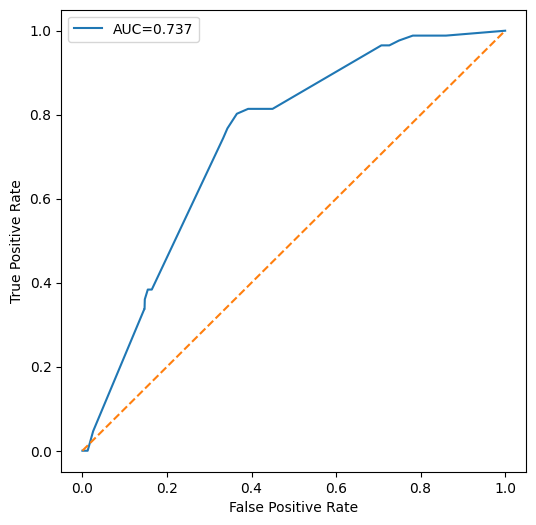

In [264]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(
    merged["label"],
    -merged["closest"]
)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC={auc_closest:.3f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

어떤 Terpeoid가 어떤 질병에 대해 새로운 치료 후보로 예측되는지 찾아보기

In [265]:
# 유망한 Terpenoid - Disease 후보 확인하기

# 실제 네트워크 거리 확인 

merged.sort_values("closest").head(50)

,Unnamed: 0,disease,n_mapped_disease,n_mapped_chemical,chemical,shortest,closest,z_shortest,z_closest,avg_shortest,std_shortest,avg_closest,std_closest,label
1510,0,liver diseases,81,1,oleocanthal,2.135802,0.0,-1.171581,-2.767274,2.293494,0.134597,1.3370,0.483147,0
1318,0,neoplasms,531,1,oleocanthal,2.161959,0.0,-0.434021,-3.646028,2.218608,0.130523,0.9360,0.256718,0
1702,0,female urogenital diseases and pregnancy compl...,275,1,oleocanthal,2.276364,0.0,0.163566,-4.935820,2.258625,0.108447,0.9840,0.199359,0
1192,0,neoplasms by site,281,1,oleocanthal,2.217082,0.0,0.147613,-4.247753,2.200100,0.115045,0.9690,0.228121,0
1693,0,"genetic diseases, inborn",960,2,propofol,2.263542,0.0,-1.076401,-3.624843,2.437313,0.161437,1.0305,0.284288,0
868,0,female urogenital diseases,264,1,oleocanthal,2.280303,0.0,0.214819,-3.885953,2.255527,0.115337,0.9800,0.252190,0
70,0,urologic neoplasms,37,1,oleocanthal,2.081081,0.0,-1.050345,-2.580645,2.230919,0.142656,1.3650,0.528938,0
469,0,"congenital, hereditary, and neonatal diseases ...",1129,2,propofol,2.281222,0.0,-0.934484,-3.336308,2.428325,0.157416,0.9995,0.299583,0
1330,0,adenocarcinoma,32,1,oleocanthal,2.000000,0.0,-1.566177,-2.737589,2.239781,0.153100,1.4310,0.522723,0
1186,0,"neoplasms, glandular and epithelial",94,1,oleocanthal,2.021277,0.0,-1.346184,-3.433341,2.179989,0.117898,1.0730,0.312524,0


In [266]:
# 랜덤 네트워크 대비 얼마나 특별하게 가까운지 확인, 일반적으로 z_closest 결과를 바탕으로 문헌조사를 진행함. 

merged.sort_values("z_closest").head(50)

,Unnamed: 0,disease,n_mapped_disease,n_mapped_chemical,chemical,shortest,closest,z_shortest,z_closest,avg_shortest,std_shortest,avg_closest,std_closest,label
1702,0,female urogenital diseases and pregnancy compl...,275,1,oleocanthal,2.276364,0.000000,0.163566,-4.935820,2.258625,0.108447,0.984000,0.199359,0
544,0,gastrointestinal diseases,262,1,oleocanthal,2.209924,0.000000,0.060279,-4.617480,2.202504,0.123092,0.969000,0.209855,0
1192,0,neoplasms by site,281,1,oleocanthal,2.217082,0.000000,0.147613,-4.247753,2.200100,0.115045,0.969000,0.228121,0
1768,0,digestive system diseases,368,1,oleocanthal,2.211957,0.000000,-0.164018,-4.042329,2.230231,0.111417,0.960000,0.237487,0
868,0,female urogenital diseases,264,1,oleocanthal,2.280303,0.000000,0.214819,-3.885953,2.255527,0.115337,0.980000,0.252190,0
1350,0,varicose veins,28,2,celastrol,2.232143,1.000000,-1.821589,-3.708083,2.425857,0.106344,1.871500,0.235027,0
1318,0,neoplasms,531,1,oleocanthal,2.161959,0.000000,-0.434021,-3.646028,2.218608,0.130523,0.936000,0.256718,0
1693,0,"genetic diseases, inborn",960,2,propofol,2.263542,0.000000,-1.076401,-3.624843,2.437313,0.161437,1.030500,0.284288,0
1576,0,neoplasms by histologic type,306,1,oleocanthal,2.078431,0.000000,-0.674281,-3.568929,2.158735,0.119096,0.941000,0.263665,0
960,0,skin diseases,310,2,celastrol,2.172581,0.500000,-0.313599,-3.501613,2.199953,0.087285,0.974000,0.135366,0


In [267]:
# 이 결과를 확인하여 두 값들이 클수록 좋은지 낮을수록 좋은지 확인. 
# 밑의 결과를 확인했을 때
merged[["closest","z_closest"]].head(20)

,closest,z_closest
0,1.500000,1.194771
1,0.500000,-3.340369
2,3.000000,3.137284
3,1.500000,-0.994737
4,1.000000,-0.888205
5,2.500000,1.964741
6,1.500000,0.176806
7,2.000000,1.254119
8,3.000000,2.295559
9,2.000000,1.493389


closest는 단순거리이고, z_closest는 랜덤 네트워크 대비 얼마나 유의하게 가까운가임.

closest
=
실제 Terpenoid target ↔ Disease gene 거리

z_closest
=
그 거리가 랜덤 단백질 집합과 비교했을 때
얼마나 특별하게 가까운지를 나타내는 통계량

즉, closest 값은 원래 네트워크가 가까워서 terpenoid target과 Disea gene 거리가 가까울 수도 있는데
실제로 유의미해서 가까운건지를 z_closest가 확인시켜주는거임

In [270]:
# 문헌조사 해보면 좋을 후보들 찾으면 됨

In [274]:
# 후보 추리기
# label = 0
# → CTD therapeutic association에는 없음

# z_closest 오름차순
# → 가장 음수인 것부터 정렬
# → 랜덤 대비 가장 유의하게 가까운 후보부터 보기

novel = merged[
    merged["label"] == 0
].sort_values("z_closest")

top30 = novel[
    ["chemical","disease","closest","z_closest"]
].head(30)

In [275]:
# 상위 30개 csv로 저장

top30.to_csv("Top30_Terpenoid_Candidates.csv", index=False)

위의 csv를 확인해보고 문헌조사 진행하기

In [276]:
# 각 후보 chemical들에 대해 질병이 너무 많이 연결되어있음

novel["chemical"].value_counts().head(20)

oleocanthal      294
idebenone        294
bolinaquinone    294
gossypol         286
propofol         264
celastrol        262
Name: chemical, dtype: int64

In [277]:
# 긱 chemcial과 연관된 disease가 약 300개씩 묶여있으므로 실제 어떤 disease가 chemical과 연관되어있는 지 확인 후 문헌조사 진행하는 것이 좋아보임

best_per_chemical = (
    novel
    .sort_values("z_closest")
    .groupby("chemical")
    .head(1)
)

best_per_chemical[
    ["chemical","disease","closest","z_closest"]
]

,chemical,disease,closest,z_closest
1702,oleocanthal,female urogenital diseases and pregnancy compl...,0.000000,-4.935820
1350,celastrol,varicose veins,1.000000,-3.708083
1693,propofol,"genetic diseases, inborn",0.000000,-3.624843
452,idebenone,"bone diseases, developmental",1.000000,-3.231235
1059,gossypol,parkinsonian disorders,1.416667,-3.032016
677,bolinaquinone,lung diseases,1.875000,-0.819958


In [278]:
prox = pd.read_csv(
    "/work/home/sjkim/DNA_to_Protein/Spring/Github/out_proximity_terpen_r1000/merged_zscore_proximity.csv"
)

print("Unique chemicals:", prox["chemical"].nunique())
print("Unique diseases :", prox["disease"].nunique())

Unique chemicals: 26
Unique diseases : 299


In [279]:
# AUC 구하기 

from sklearn.metrics import roc_auc_score
import pandas as pd

chem_auc_results = []

for chem in sorted(merged["chemical"].unique()):
    tmp = merged[merged["chemical"] == chem].copy()
    
    n_total = len(tmp)
    n_pos = tmp["label"].sum()
    n_neg = n_total - n_pos
    
    # label이 0/1 둘 다 있어야 AUC 계산 가능
    if tmp["label"].nunique() < 2:
        chem_auc_results.append({
            "chemical": chem,
            "n_pairs": n_total,
            "n_positive": n_pos,
            "n_negative": n_neg,
            "auc_closest": None,
            "auc_shortest": None,
            "status": "Only one class"
        })
        continue
    
    auc_closest = roc_auc_score(
        tmp["label"],
        -tmp["closest"]
    )
    
    auc_shortest = roc_auc_score(
        tmp["label"],
        -tmp["shortest"]
    )
    
    chem_auc_results.append({
        "chemical": chem,
        "n_pairs": n_total,
        "n_positive": n_pos,
        "n_negative": n_neg,
        "auc_closest": auc_closest,
        "auc_shortest": auc_shortest,
        "status": "OK"
    })

chem_auc = pd.DataFrame(chem_auc_results)

chem_auc = chem_auc.sort_values(
    "auc_closest",
    ascending=False,
    na_position="last"
)

chem_auc

,chemical,n_pairs,n_positive,n_negative,auc_closest,auc_shortest,status
2,gossypol,297,11,286,0.820089,0.703274,OK
3,idebenone,297,3,294,0.790816,0.495465,OK
1,celastrol,297,35,262,0.644929,0.408233,OK
0,bolinaquinone,296,2,294,0.625850,0.198980,OK
4,oleocanthal,296,2,294,0.538265,0.299320,OK
5,propofol,297,33,264,0.520087,0.376894,OK


In [280]:
# 저장

chem_auc.to_csv(
    "/work/home/sjkim/DNA_to_Protein/Spring/Github/out_proximity_terpen_r1000/Terpenoid_individual_AUC.csv",
    index=False
)

In [281]:
chem_auc.head(10)

,chemical,n_pairs,n_positive,n_negative,auc_closest,auc_shortest,status
2,gossypol,297,11,286,0.820089,0.703274,OK
3,idebenone,297,3,294,0.790816,0.495465,OK
1,celastrol,297,35,262,0.644929,0.408233,OK
0,bolinaquinone,296,2,294,0.625850,0.198980,OK
4,oleocanthal,296,2,294,0.538265,0.299320,OK
5,propofol,297,33,264,0.520087,0.376894,OK


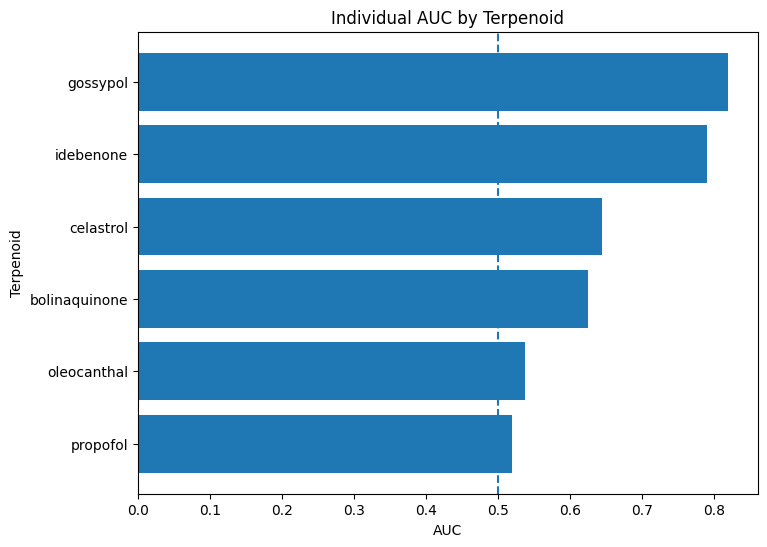

In [282]:
# 논문 figure와 같이 만들기

import matplotlib.pyplot as plt

plot_df = chem_auc[
    chem_auc["status"] == "OK"
].sort_values("auc_closest", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(plot_df["chemical"], plot_df["auc_closest"])
plt.axvline(0.5, linestyle="--")
plt.xlabel("AUC")
plt.ylabel("Terpenoid")
plt.title("Individual AUC by Terpenoid")
plt.show()

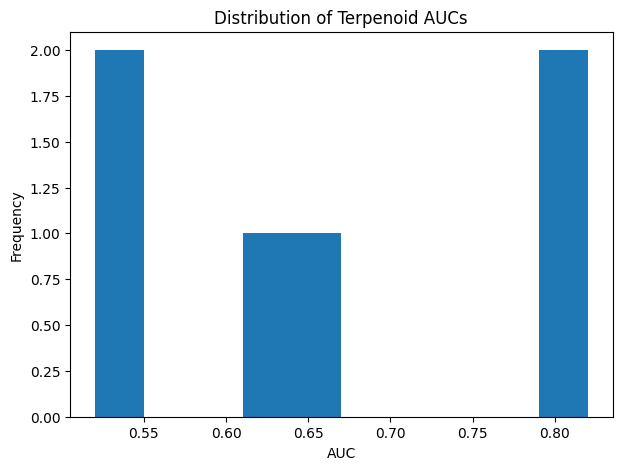

In [283]:
# 이게 논문스티일
import matplotlib.pyplot as plt

auc_values = chem_auc["auc_closest"].dropna()

plt.figure(figsize=(7,5))
plt.hist(auc_values, bins=10)

plt.xlabel("AUC")
plt.ylabel("Frequency")
plt.title("Distribution of Terpenoid AUCs")

plt.show()

In [289]:
# 26개 화합물 중 AUC를 계산할 수 있는 화합물이 6개뿐임.
# 나머지 20개는 label이 없음.

In [286]:
# 26개중 20개누락된 이유 찾기

,sum,count
chemical,,
bolinaquinone,2,296
celastrol,35,297
gossypol,11,297
idebenone,3,297
oleocanthal,2,296
propofol,33,297


In [291]:
# 1. proximity 결과의 전체 chemical
prox_chems = set(prox["chemical"].str.lower().unique())

# 2. AUC 계산에 들어간 chemical
auc_chems = set(chem_auc["chemical"].str.lower().unique())

# 3. 빠진 chemical 확인
missing_chems = sorted(prox_chems - auc_chems)

print("Proximity chemicals:", len(prox_chems))
print("AUC chemicals:", len(auc_chems))
print("Missing chemicals:", len(missing_chems))
print(missing_chems)

Proximity chemicals: 26
AUC chemicals: 6
Missing chemicals: 20
['145-14-2', '153559-76-3', '25-hydroxycholesterol', 'abiraterone', 'acylfulvene', 'am580', 'asiatic acid', 'bardoxolone', 'bexarotene', 'desoxycortone', 'galeterone', 'maslinic acid', 'obeticholic acid', 'oleanolic acid', 'picrotoxin', 'solomonsterol a', 'stx140', 'tamibarotene', 'thymol', 'thymoquinone']


In [292]:
imp_chems = set(imp["chemical"].str.lower().unique())

missing_in_imp = [c for c in missing_chems if c not in imp_chems]
present_in_imp = [c for c in missing_chems if c in imp_chems]

print("Missing chemicals not in implicit/explicit file:", len(missing_in_imp))
print(missing_in_imp)

print("Missing chemicals present in implicit/explicit file:", len(present_in_imp))
print(present_in_imp)

Missing chemicals not in implicit/explicit file: 8
['145-14-2', '153559-76-3', 'am580', 'bardoxolone', 'desoxycortone', 'galeterone', 'solomonsterol a', 'stx140']
Missing chemicals present in implicit/explicit file: 12
['25-hydroxycholesterol', 'abiraterone', 'acylfulvene', 'asiatic acid', 'bexarotene', 'maslinic acid', 'obeticholic acid', 'oleanolic acid', 'picrotoxin', 'tamibarotene', 'thymol', 'thymoquinone']


In [293]:
label_summary = merged.groupby("chemical")["label"].agg(
    n_pairs="count",
    n_positive="sum"
).reset_index()

label_summary["n_negative"] = label_summary["n_pairs"] - label_summary["n_positive"]

label_summary.sort_values("n_positive")

,chemical,n_pairs,n_positive,n_negative
0,bolinaquinone,296,2,294
4,oleocanthal,296,2,294
3,idebenone,297,3,294
2,gossypol,297,11,286
5,propofol,297,33,264
1,celastrol,297,35,262


In [294]:
set(prox["chemical"].str.lower()) - set(merged["chemical"].str.lower())

{'145-14-2',
 '153559-76-3',
 '25-hydroxycholesterol',
 'abiraterone',
 'acylfulvene',
 'am580',
 'asiatic acid',
 'bardoxolone',
 'bexarotene',
 'desoxycortone',
 'galeterone',
 'maslinic acid',
 'obeticholic acid',
 'oleanolic acid',
 'picrotoxin',
 'solomonsterol a',
 'stx140',
 'tamibarotene',
 'thymol',
 'thymoquinone'}

In [295]:
for chem in missing_chems:
    print(
        chem,
        (imp["chemical"].str.lower()==chem).sum()
    )

145-14-2 0
153559-76-3 0
25-hydroxycholesterol 4798
abiraterone 4798
acylfulvene 4798
am580 0
asiatic acid 4799
bardoxolone 0
bexarotene 4798
desoxycortone 0
galeterone 0
maslinic acid 4798
obeticholic acid 4798
oleanolic acid 4798
picrotoxin 4798
solomonsterol a 0
stx140 0
tamibarotene 4798
thymol 4798
thymoquinone 4799


In [296]:
sorted(
    imp["chemical"].str.lower().unique()
)

['(22r, 25r)-20alpha-spirost-5-en-3beta-yl hexanoate',
 '1 alpha,24-dihydroxyvitamin d3',
 '1 alpha-hydroxyergocalciferol',
 '1,25-dihydroxyvitamin d',
 '1-(2-cyano-3,12-dioxooleana-1,9-dien-28-oyl) imidazole',
 '1-hydroxyalantolactone',
 '11-keto-boswellic acid',
 '17 alpha-hydroxyprogesterone caproate',
 '17-ethynyl-5-androstene-3, 7, 17-triol',
 '17-hydroxyjolkinolide b',
 "2''-o-acetyl-polygalacin d2",
 '2,7,8-trimethyl-2-(beta-carboxyethyl)-6-hydroxychroman',
 '2-cyano-3,12-dioxoolean-1,9-dien-28-oic acid',
 '2-hydroxyestradiol',
 '2-methoxyestradiol',
 '2-methoxyestradiol-3,17-bis-o,o-sulfamate',
 '2-methoxyestradiol-3,17-o,o-bis(sulfamate)',
 '2-methoxyoestra-1,3,5(10),16-tetraene-3-carboxamide',
 '2-methylene-19-nor-(20s)-1 alpha-hydroxy-bishomopregnacalciferol',
 '20-alpha-dihydroprogesterone',
 '23-hydroxytormentic acid',
 '24-methylenecycloartenol',
 '25-hydroxycholesterol',
 '25-hydroxyprotopanaxadiol',
 '25-hydroxyvitamin d',
 '28-deoxonimbolide',
 "3-geranyl-4-hydroxy-5-(